# **Taller Imputación de Datos**

## **Librerias:**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.experimental import enable_iterative_imputer  # Necesario para habilitar IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn.impute import KNNImputer
from scipy.stats import chi2_contingency
from sklearn.preprocessing import OrdinalEncoder
from statsmodels.stats.weightstats import ttest_ind as sm_ttest


## **Funciones:**

In [ ]:
def chi2_imputacion(df_before, df_after, categorical_vars):
    resultados = []
    
    for var in categorical_vars:
        # Crear tabla de frecuencias antes y después
        before_counts = df_before[var].value_counts()
        after_counts = df_after[var].value_counts()
        
        # Unificar categorías (en caso de que falten en alguno)
        all_categories = sorted(set(before_counts.index) | set(after_counts.index))
        before_aligned = before_counts.reindex(all_categories, fill_value=0)
        after_aligned = after_counts.reindex(all_categories, fill_value=0)
        
        # Construir tabla de contingencia
        tabla = pd.DataFrame({
            "Antes": before_aligned,
            "Después": after_aligned
        })
        
        # Prueba Chi-cuadrado
        chi2, p, dof, expected = chi2_contingency(tabla.T)
        
        resultados.append({
            "Variable": var,
            "Chi2": chi2,
            "p-valor": p,
            "GL": dof,
            "Conclusión": "Distribuciones diferentes" if p < 0.05 else "Distribuciones iguales"
        })
    
    return pd.DataFrame(resultados)


In [3]:
def comparar_imputacion(df_original, df_imputado, variable):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Comparación antes y después de la imputación: {variable}", fontsize=14, fontweight="bold")

    # Histograma antes
    axes[0,0].hist(df_original[variable].dropna(), bins=30, edgecolor="black", alpha=0.7)
    axes[0,0].set_title("Histograma - Antes")
    axes[0,0].set_xlabel(variable)
    axes[0,0].set_ylabel("Frecuencia")

    # Histograma después
    axes[0,1].hist(df_imputado[variable].dropna(), bins=30, edgecolor="black", alpha=0.7, color="orange")
    axes[0,1].set_title("Histograma - Después")
    axes[0,1].set_xlabel(variable)
    axes[0,1].set_ylabel("Frecuencia")

    # Boxplot antes
    axes[1,0].boxplot(df_original[variable].dropna(), vert=True, patch_artist=True)
    axes[1,0].set_title("Boxplot - Antes")
    axes[1,0].set_ylabel(variable)

    # Boxplot después
    axes[1,1].boxplot(df_imputado[variable].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor="orange"))
    axes[1,1].set_title("Boxplot - Después")
    axes[1,1].set_ylabel(variable)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


In [ ]:
def comparar_distribucion_imputacion(df_original, df_imputado, variable):    
    # Obtener datos antes (excluyendo NaN) y después de la imputación
    datos_antes = df_original[variable].dropna()
    datos_despues = df_imputado[variable]
    
    # Configurar el gráfico
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Gráfico de datos originales (antes de imputación)
    ax[0].hist(datos_antes, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax[0].set_title(f'Antes de imputación\n(N={len(datos_antes)})')
    ax[0].set_xlabel(variable)
    ax[0].set_ylabel('Frecuencia')
    
    # Gráfico de datos imputados (después de imputación)
    ax[1].hist(datos_despues, bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
    ax[1].set_title(f'Después de imputación\n(N={len(datos_despues)})')
    ax[1].set_xlabel(variable)
    ax[1].set_ylabel('Frecuencia')
    
    # Ajustar layout
    plt.tight_layout()
    plt.show()

In [ ]:
def prueba_normalidad(df, variables):
    print("Resultados de la prueba de Shapiro-Wilk:\n")
    for col in variables:
        serie = df[col].dropna()
        if len(serie) > 3:  # evitar error en series con muy pocos datos
            stat, p_value = stats.shapiro(serie)
            conclusion = "Normal" if p_value >= 0.05 else "No Normal"
            print(f"Variable: {col:20} | Estadístico: {stat:.4f} | p-valor: {p_value:.4e} | {conclusion}")
    print("\nInterpretación: p < 0.05 → No normal | p ≥ 0.05 → Normal")

In [ ]:
def prueba_ks(df_original, df_imputado, variables):
    print("Resultados de Kolmogorov-Smirnov (KS test):\n")
    for col in variables:
        # Tomar datos sin NaN en el original
        serie_original = df_original[col].dropna()
        serie_imputada = df_imputado[col].dropna()
        
        if len(serie_original) > 3 and len(serie_imputada) > 3:
            stat, p_value = stats.ks_2samp(serie_original, serie_imputada)
            conclusion = "Distribuciones Iguales" if p_value >= 0.05 else "Distribuciones Diferentes"
            
            print(f"Variable: {col:20} | KS Estadístico: {stat:.4f} | p-valor: {p_value:.4e} | {conclusion}")
    
    print("\nInterpretación: p < 0.05 → Distribuciones diferentes | p ≥ 0.05 → Distribuciones iguales")

In [ ]:
def comparar_tstudent(df_original, df_imputado, variables, alpha=0.05):
    print("Comparación de medias con T de Student:\n")

    for col in variables:
        orig = df_original[col].dropna()
        imp = df_imputado[col].dropna()

        if len(orig) < 3 or len(imp) < 3:
            print(f"Variable {col}: muy pocos datos para probar.")
            continue

        stat, p_val = stats.ttest_ind(orig, imp, equal_var=False)
        conclusion = "No hay diferencia significativa" if p_val >= alpha else "Diferencia significativa"

        print(f"Variable: {col:20} | Estadístico: {stat:.4f} | p-valor: {p_val:.4e} | {conclusion}")

    print(f"\nInterpretación: p < {alpha} → diferencia significativa | p ≥ {alpha} → no significativa")


In [ ]:
def comparar_mannwhitney(df_original, df_imputado, variables, alpha=0.05):
    print("Comparación de distribuciones con Mann–Whitney U:\n")

    for col in variables:
        orig = df_original[col].dropna()
        imp = df_imputado[col].dropna()

        if len(orig) < 3 or len(imp) < 3:
            print(f"Variable {col}: muy pocos datos para probar.")
            continue

        stat, p_val = stats.mannwhitneyu(orig, imp, alternative="two-sided")
        conclusion = "No hay diferencia significativa" if p_val >= alpha else "Diferencia significativa"

        print(f"Variable: {col:20} | Estadístico: {stat:.4f} | p-valor: {p_val:.4e} | {conclusion}")

    print(f"\nInterpretación: p < {alpha} → diferencia significativa | p ≥ {alpha} → no significativa")


In [ ]:
def plot_missing_vs_numeric(df, numeric_vars, ncols=3):
    for var in numeric_vars:
        # Crear indicador de nulos
        missing_col = f"missing_{var}"
        df[missing_col] = df[var].isnull().astype(int)
        
        # Crear grid para graficar contra las demás numéricas
        others = [v for v in numeric_vars if v != var]
        nrows = -(-len(others) // ncols)  # redondeo hacia arriba
        
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
        axes = axes.flatten()
        
        for i, other in enumerate(others):
            sns.boxplot(x=missing_col, y=other, data=df, ax=axes[i])
            axes[i].set_xlabel(f"{var} nulo (0=no, 1=sí)")
            axes[i].set_ylabel(other)
        
        # Eliminar ejes vacíos
        for j in range(len(others), len(axes)):
            fig.delaxes(axes[j])
        
        fig.suptitle(f"Impacto de los nulos en {var}", fontsize=16)
        plt.tight_layout()
        plt.show()


In [ ]:
def clasificar_nulos_categoricos(df, threshold_p=0.05, min_rows=30):
    resultados = []

    cat_vars = df.select_dtypes(include=["object", "category"]).columns.tolist()
    num_vars = df.select_dtypes(include=["number"]).columns.tolist()

    for var in cat_vars:
        if df[var].isnull().sum() == 0:
            continue  # Saltar si no hay nulos

        df_temp = df.copy()
        df_temp[f"{var}_isnull"] = df_temp[var].isnull().astype(int)

        asociaciones = []

        # Comparación con otras categóricas
        for cat in [c for c in cat_vars if c != var]:
            tabla = pd.crosstab(df_temp[cat], df_temp[f"{var}_isnull"])
            if tabla.shape[0] > 1 and tabla.shape[1] == 2:
                try:
                    chi2, p, _, _ = chi2_contingency(tabla)
                    asociaciones.append(("cat", cat, p))
                except:
                    continue

        # Comparación con numéricas
        for num in num_vars:
            grupo_nulo = df_temp[df_temp[f"{var}_isnull"] == 1][num].dropna()
            grupo_no_nulo = df_temp[df_temp[f"{var}_isnull"] == 0][num].dropna()

            if len(grupo_nulo) >= min_rows and len(grupo_no_nulo) >= min_rows:
                try:
                    t_stat, p, _ = sm_ttest(grupo_nulo, grupo_no_nulo, usevar="unequal")
                    asociaciones.append(("num", num, p))
                except:
                    continue

        # Clasificación según p-values
        asociados = [a for a in asociaciones if a[2] < threshold_p]
        clasificacion = "MCAR" if len(asociados) == 0 else "MAR"

        resultados.append({
            "variable": var,
            "nulos (%)": round(100 * df[var].isnull().mean(), 2),
            "asociaciones_significativas": len(asociados),
            "clasificacion": clasificacion,
            "detalles": [(tipo, v, round(p, 4)) for tipo, v, p in asociados]
        })

    return pd.DataFrame(resultados)



# **1. Exploración Inicial de las Variables:**

In [9]:
df = pd.read_csv("base_imputacion_mixta_1000.csv")
df.head()

,fecha,sexo,ciudad,nivel_educativo,segmento,estado_civil,edad,altura_cm,ingresos,gasto_mensual,puntuacion_credito,demanda
0,2024-01-01,F,Medellín,NaN,B,Unión libre,19.0,161.821754,3574.753806,1832.731832,640.465372,119.202995
1,2024-01-02,F,Barranquilla,NaN,B,NaN,52.0,167.819566,3163.626815,NaN,533.108430,124.457874
2,2024-01-03,M,Bogotá,Secundaria,B,Soltero/a,38.0,165.756219,2765.672259,1219.535074,491.016910,NaN
3,2024-01-04,F,Bogotá,NaN,B,Casado/a,57.0,160.642670,4320.397345,1908.324816,NaN,129.426792
4,2024-01-05,M,Cali,Técnico,B,Soltero/a,67.0,151.402909,NaN,1887.385697,610.213994,133.916319


In [10]:
df.dtypes

fecha                  object
sexo                   object
ciudad                 object
nivel_educativo        object
segmento               object
estado_civil           object
edad                  float64
altura_cm             float64
ingresos              float64
gasto_mensual         float64
puntuacion_credito    float64
demanda               float64
dtype: object

Encontramos que  tenemos 6 variables cuantitativas y 6 variables cualitativas:

**Cuantitativas:**
- edad
- altura_cm
- ingresos
- gasto_mensual
- puntuacion_credito
- demanda

**Cualitativas:**
- fecha
- sexo
- ciudad
- nivel_educativo
- segmento
- estado_civil


In [11]:
num_var = ["edad","altura_cm","ingresos","gasto_mensual",
           "puntuacion_credito","demanda"]

cat_var = ["fecha","sexo","ciudad","nivel_educativo",
           "segmento","estado_civil"]

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fecha               1000 non-null   object 
 1   sexo                980 non-null    object 
 2   ciudad              950 non-null    object 
 3   nivel_educativo     900 non-null    object 
 4   segmento            800 non-null    object 
 5   estado_civil        650 non-null    object 
 6   edad                970 non-null    float64
 7   altura_cm           920 non-null    float64
 8   ingresos            880 non-null    float64
 9   gasto_mensual       750 non-null    float64
 10  puntuacion_credito  500 non-null    float64
 11  demanda             850 non-null    float64
dtypes: float64(6), object(6)
memory usage: 93.9+ KB


In [13]:
df.describe()

,edad,altura_cm,ingresos,gasto_mensual,puntuacion_credito,demanda
count,970.000000,920.000000,880.000000,750.000000,500.000000,850.000000
mean,42.861856,167.760096,3681.294745,1687.810749,599.077500,160.305759
std,14.621382,9.275530,1079.326096,582.070174,79.828186,25.357794
min,18.000000,140.000000,487.662547,100.000000,373.657944,99.875828
25%,30.000000,161.488768,2999.416229,1309.239768,544.467843,139.505538
50%,43.000000,167.714614,3669.620507,1676.193764,599.692595,160.721251
75%,55.000000,173.999069,4375.093656,2063.260990,653.345068,181.100754
max,69.000000,195.766921,7016.246936,3532.593603,823.539585,222.093047


In [14]:
df.describe(include="object")

,fecha,sexo,ciudad,nivel_educativo,segmento,estado_civil
count,1000,980,950,900,800,650
unique,1000,2,5,4,3,4
top,2026-09-26,F,Bogotá,Secundaria,B,Soltero/a
freq,1,518,307,317,457,290


# **2. Detección de Valores Faltaantes:**

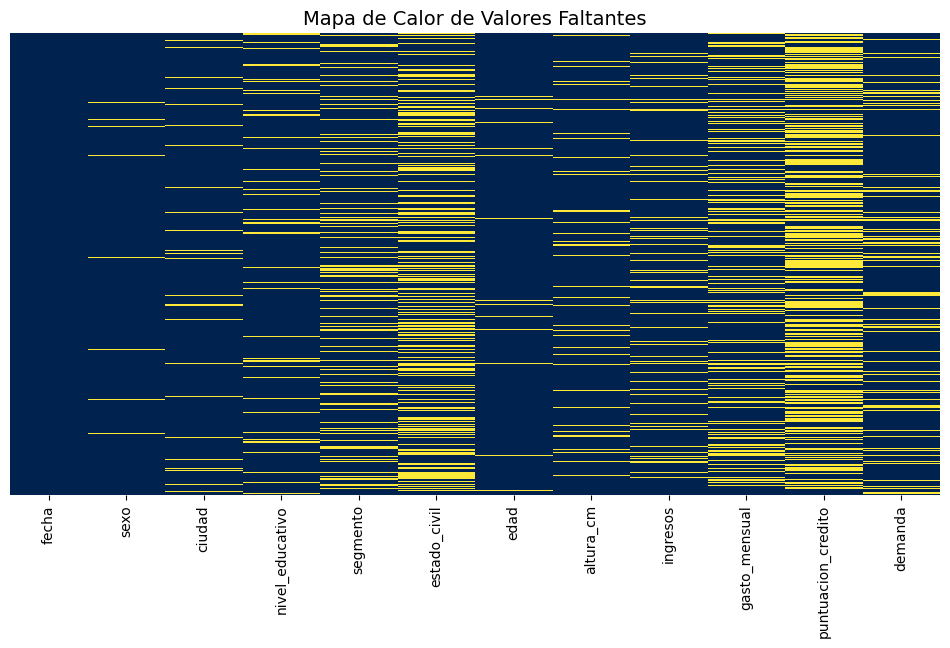

In [15]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='cividis')
plt.title("Mapa de Calor de Valores Faltantes", fontsize = 14)
plt.show()

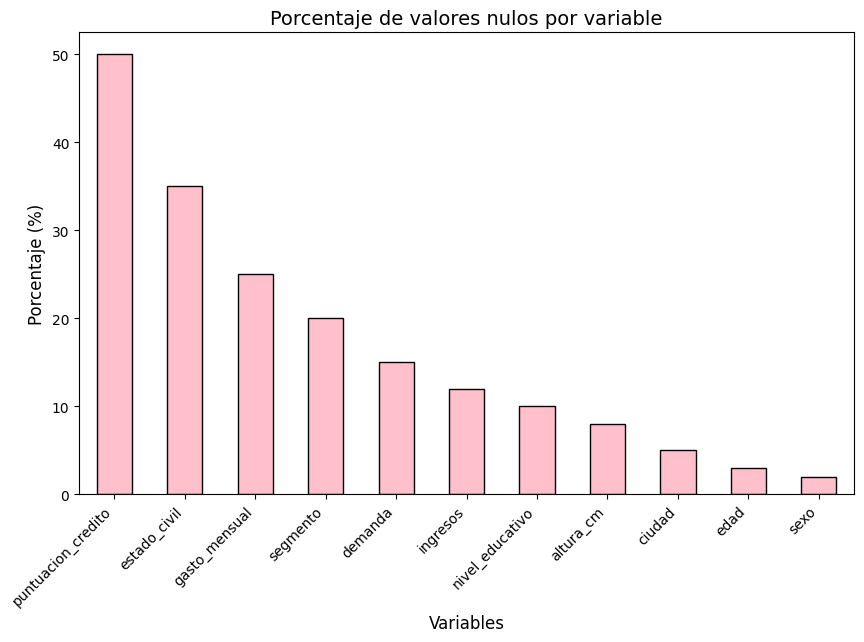

In [16]:
# --- Calcular porcentaje de nulos ---
missing_percent = df.isnull().mean() * 100  # porcentaje
missing_percent = missing_percent[missing_percent > 0]  # solo variables con nulos

# --- Gráfico de barras ---
plt.figure(figsize=(10,6))
missing_percent.sort_values(ascending=False).plot.bar(color="pink", edgecolor="black")

plt.title("Porcentaje de valores nulos por variable", fontsize=14)
plt.ylabel("Porcentaje (%)", fontsize=12)
plt.xlabel("Variables", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.show()

In [17]:
faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df)) * 100

tabla_faltantes = pd.DataFrame({
    'Valores faltantes': faltantes,
    'Porcentaje (%)': porcentaje
})

# Mostrar solo columnas con NA
tabla_faltantes = tabla_faltantes[tabla_faltantes['Valores faltantes'] > 0]
tabla_faltantes.sort_values('Porcentaje (%)', ascending=False)

,Valores faltantes,Porcentaje (%)
puntuacion_credito,500,50.0
estado_civil,350,35.0
gasto_mensual,250,25.0
segmento,200,20.0
demanda,150,15.0
ingresos,120,12.0
nivel_educativo,100,10.0
altura_cm,80,8.0
ciudad,50,5.0
edad,30,3.0


# **3. Clasificación del Tipo de Faltante:**

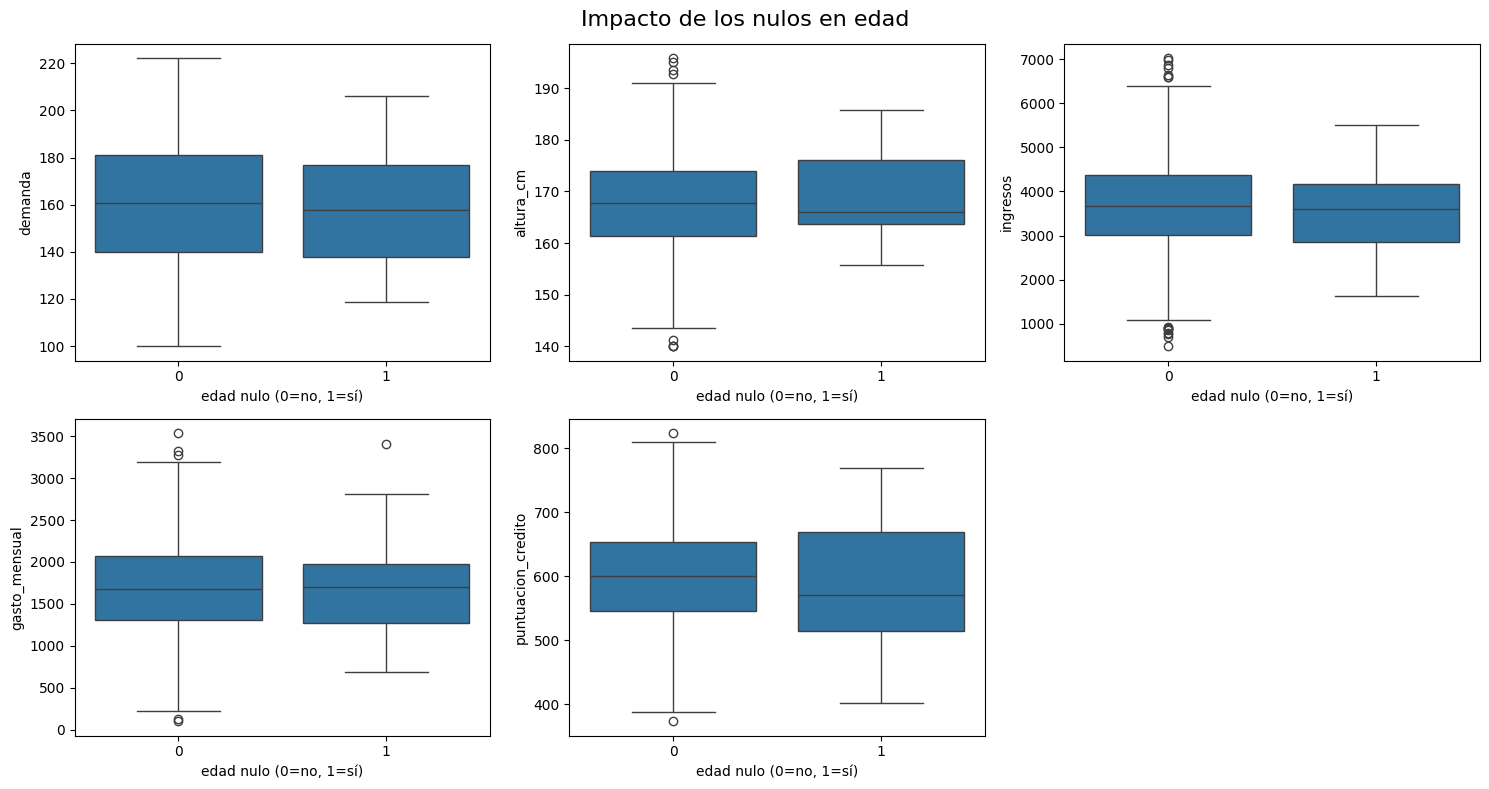

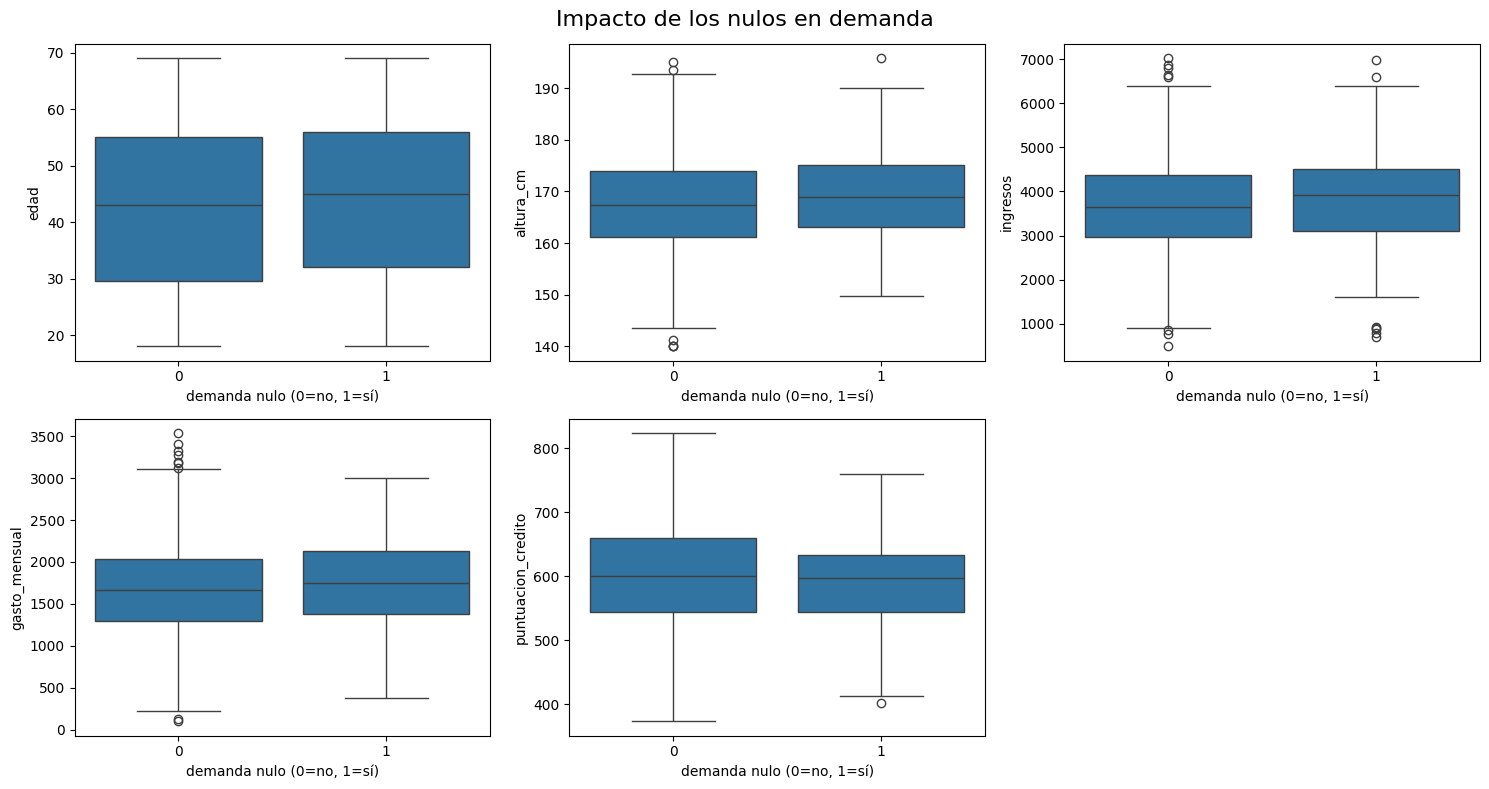

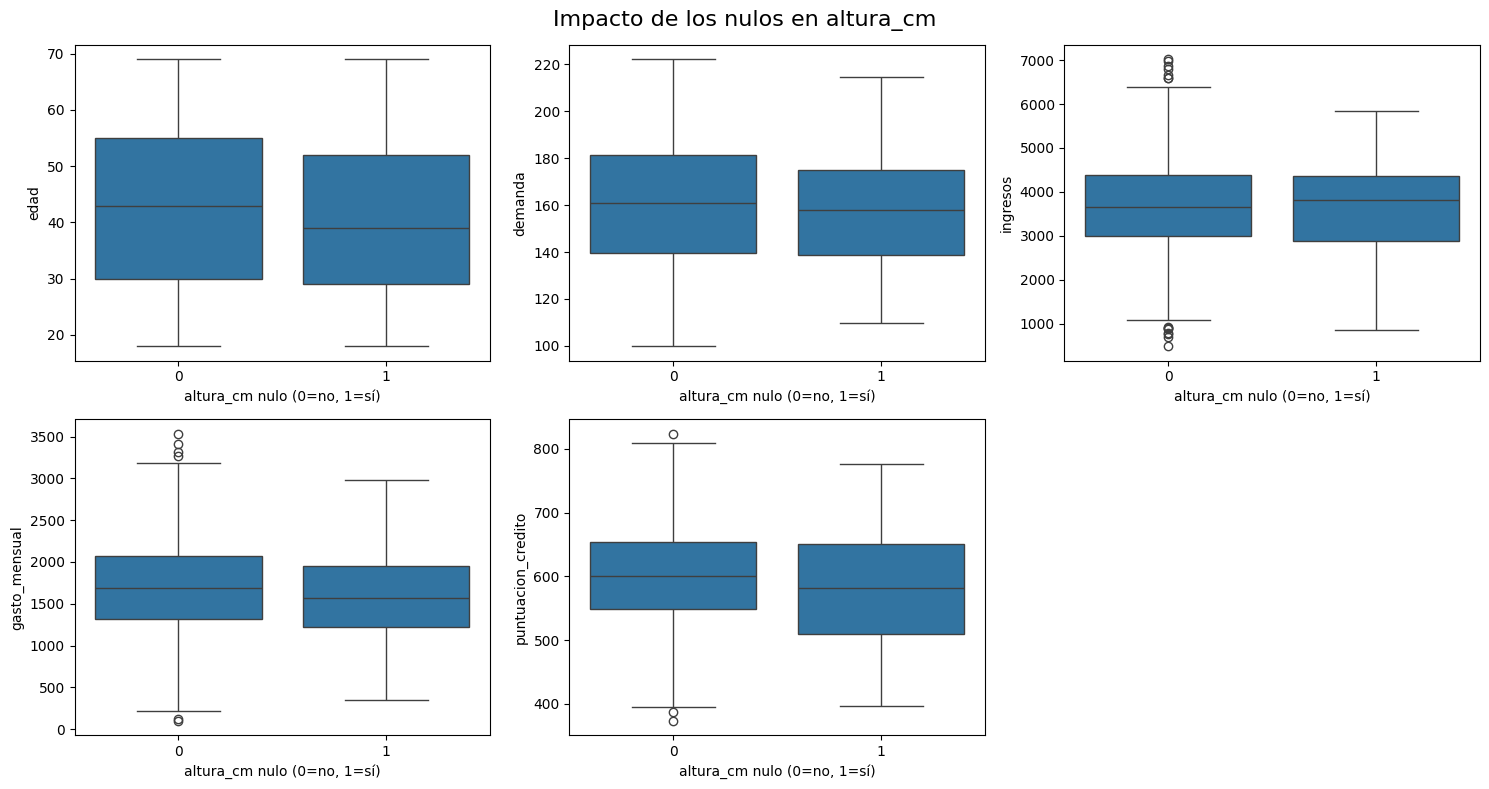

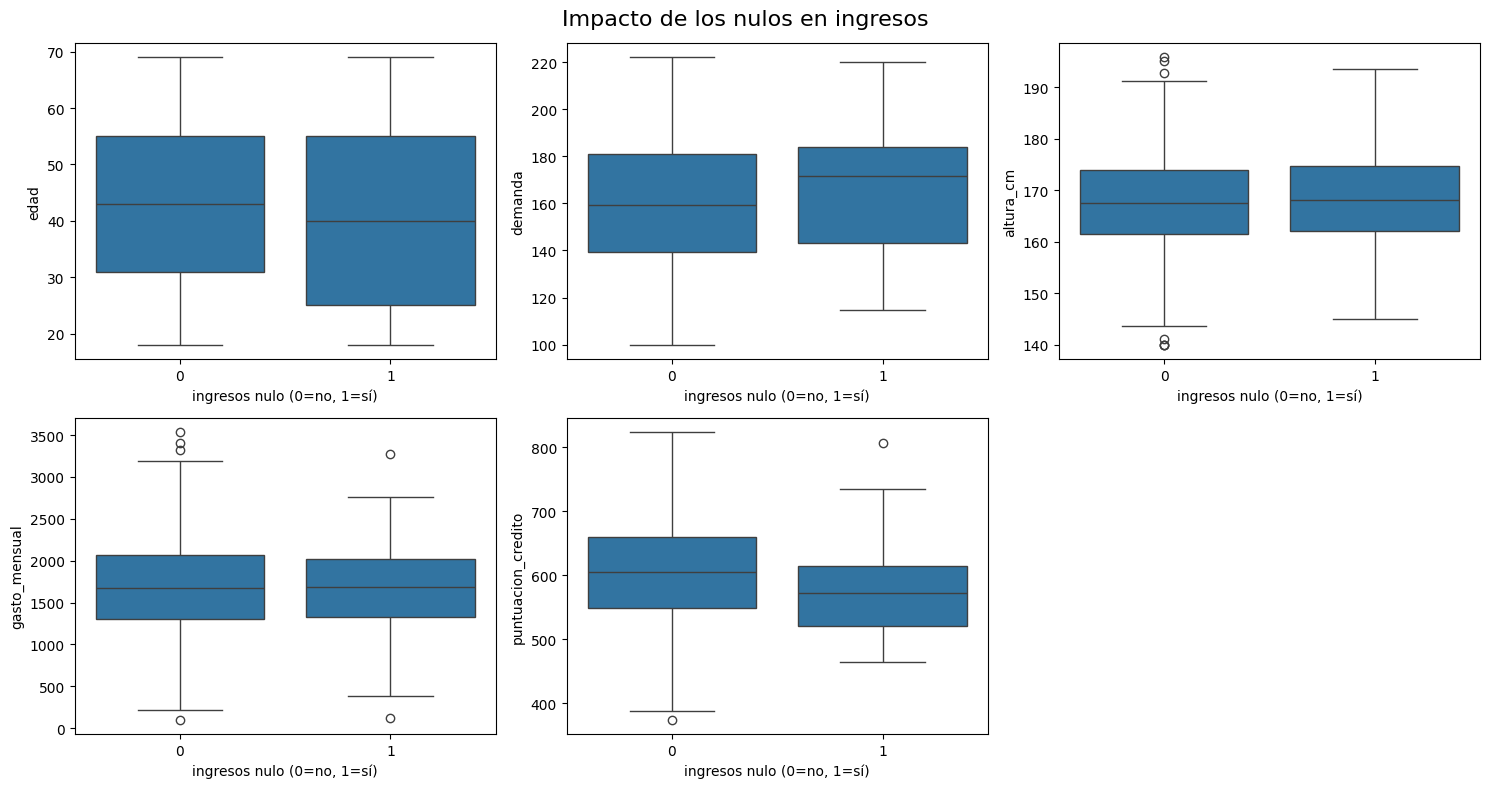

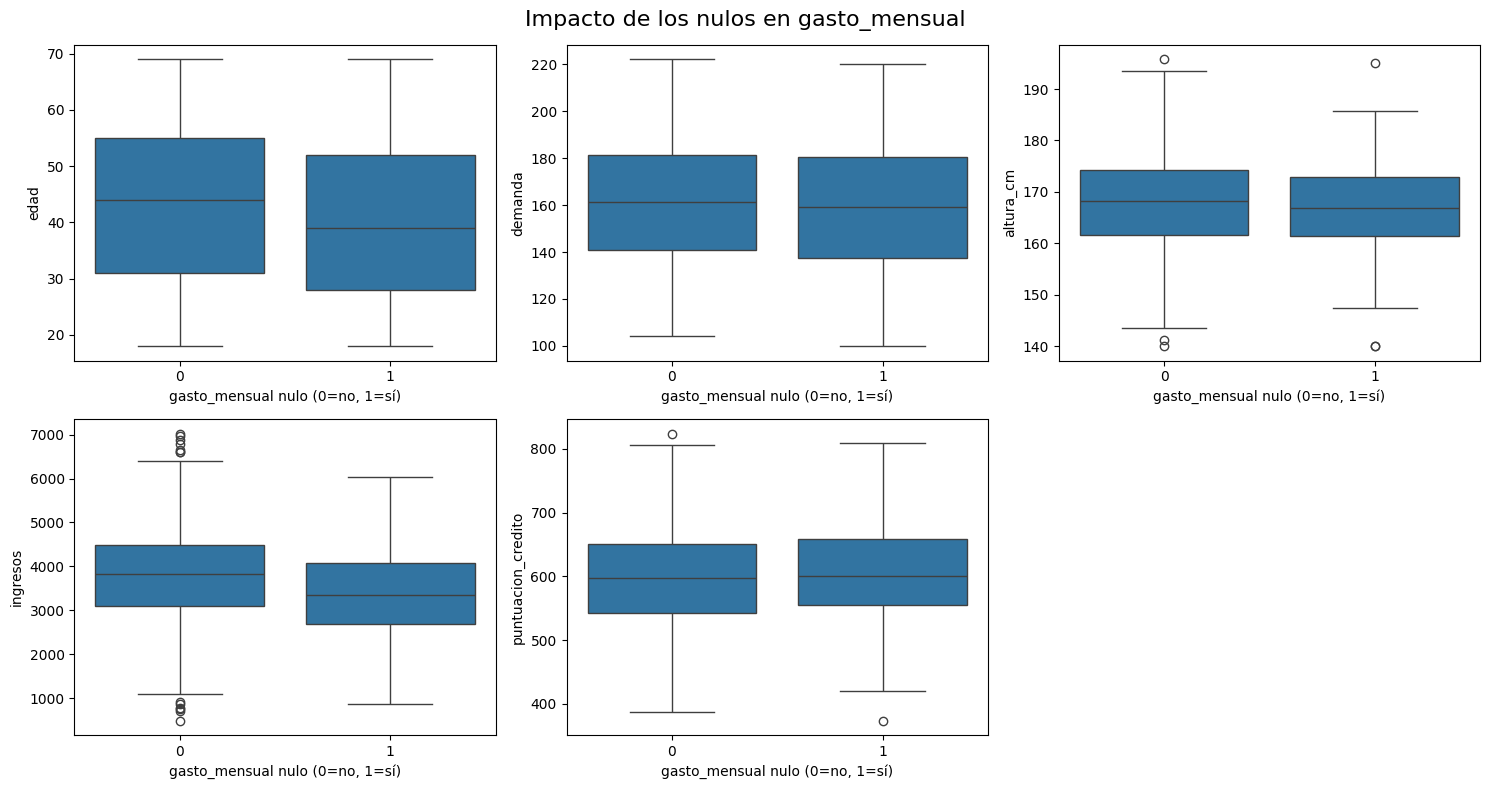

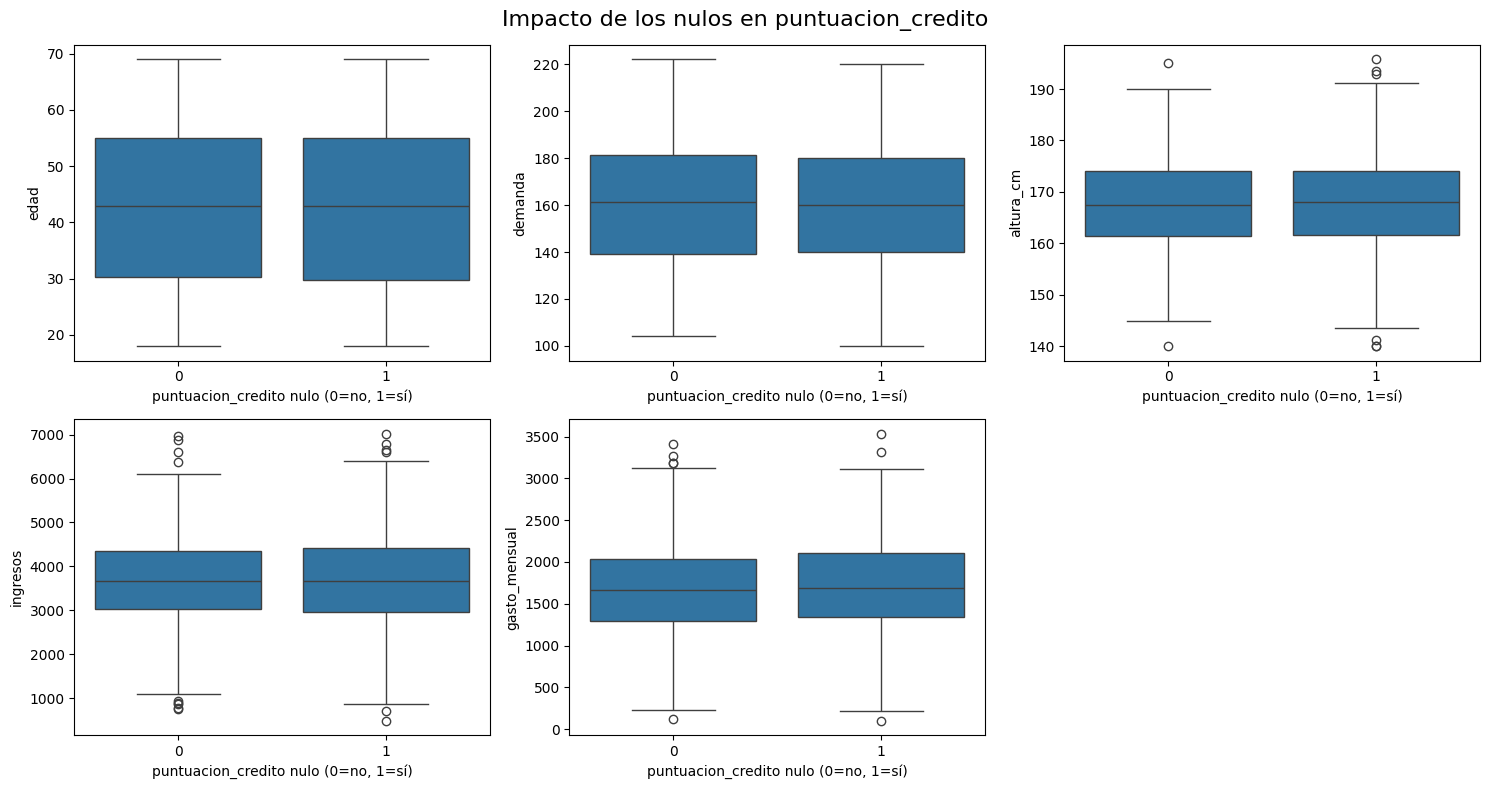

In [88]:
# Ejemplo de uso con tus variables numéricas
numeric_vars = ["edad", "demanda", "altura_cm", "ingresos", "gasto_mensual", "puntuacion_credito"]
plot_missing_vs_numeric(df, numeric_vars, ncols=3)



Se observa que la mayoría de los casos presentan diferencias en variables observadas, lo que indica que los datos no faltan completamente al azar. Las variables edad, demanda, altura_cm, ingresos y gasto_mensual muestran ligeras o moderadas diferencias en variables como ingresos, gasto_mensual, puntuación de crédito y edad al comparar los grupos con y sin datos faltantes. Esto sugiere que la presencia de valores nulos en estas variables depende de otras variables observadas, pero no necesariamente del valor faltante en sí. Por esta razón, los nulos en estas variables se clasifican como MAR (Missing At Random), ya que su ausencia está condicionada por información disponible en el resto del conjunto de datos.

En cambio, la variable puntuacion_credito no presenta diferencias claras entre los grupos con y sin nulos en ninguna de las variables observadas. Las distribuciones son muy similares, lo que indica que la ausencia de datos en esta variable no depende ni de las variables observadas ni de la propia puntuación de crédito. Esto es característico de datos faltantes MCAR (Missing Completely At Random), donde la falta de información es completamente aleatoria y no introduce sesgo en el análisis si se maneja adecuadamente.

In [93]:
clasificacion = clasificar_nulos_categoricos(df)
print(clasificacion)



          variable  nulos (%)  asociaciones_significativas clasificacion  \
0             sexo        2.0                            0          MCAR   
1           ciudad        5.0                            0          MCAR   
2  nivel_educativo       10.0                            2           MAR   
3         segmento       20.0                            0          MCAR   
4     estado_civil       35.0                            0          MCAR   

                                            detalles  
0                                                 []  
1                                                 []  
2  [(num, altura_cm, 0.0316), (num, demanda, 0.04...  
3                                                 []  
4                                                 []  


La función aplicada realiza un análisis automático para clasificar los valores faltantes en todas las variables categóricas del conjunto de datos, determinando si los nulos pueden considerarse MCAR (Missing Completely At Random) o MAR (Missing At Random). Para ello, primero identifica las variables categóricas con datos faltantes y luego evalúa si la presencia de nulos en cada una está asociada significativamente con otras variables del dataset. La evaluación se realiza mediante pruebas de Chi-cuadrado para variables categóricas y t-test para variables numéricas. Si se encuentran asociaciones estadísticamente significativas (p < 0.05), se considera que los nulos dependen de variables observadas y se clasifican como MAR; si no, se asumen como completamente al azar (MCAR). A partir de este análisis, se observa que la mayoría de las variables categóricas, particularmente sexo (2% de nulos), ciudad (5%), segmento (20%) y estado_civil (35%)  no presentan asociaciones con otras variables, por lo que sus faltantes se clasifican como MCAR. Por otro lado, la variable nivel_educativo, con un 10% de nulos, mostró asociaciones significativas con variables numéricas como altura_cm y demanda, lo que indica un patrón dependiente de otras observaciones, clasificándola como MAR.

# **4. Discusión sobre Imputabilidad:**

### **Sexo, Edad, Ciudad, altura_cm, nivel_educativo, ingresos, demanda, segmento:**

**¿Se justifica imputar o dejar los valores nulos?**  
R/ En el caso de estas tres variables, resulta justificable imputar los valores faltantes, dado que el porcentaje de ausencias es muy reducido (menor o igual al 20%) y su tratamiento permitiría obtener un análisis más claro y consistente.  

**¿Qué riesgo tendría imputar estas variables?**  
R/ El riesgo es bajo debido al bajo porcentaje de valores faltantes. Al aplicar una técnica de imputación, la probabilidad de inducir sesgos significativos en el análisis es baja.  

**¿Qué técnica sería la más adecuada?**  
R/ Para las variables **Sexo**,**Ciudad**,**nivel_educativo** y **segmento** la técnica más apropiada sería la imputación mediante la **moda** o **Regresión Logistica**, mientras que, en el caso de las variables **Edad**, **altura_cm**, **ingresos** y **demanda** resulta pertinente emplear métodos como la **mediana**, **media** y **regresión** según la distribución de los datos.  


### **Gasto_Mensual y Estado_Civil:**

**¿Se justifica imputar o dejar los valores nulos?**  
R/ Dado que el porcentaje de valores faltantes se encuentra entre un 20% y un 40%, se justifica aplicar imputación; sin embargo, es necesario hacerlo con mayor precaución.  

**¿Qué riesgo tendría imputar estas variables?**  
R/ El riesgo aumenta en comparación con porcentajes inferiores al 20%. No obstante, aún es posible realizar la imputación siempre que se apliquen técnicas adecuadas.  

**¿Qué técnica sería la más adecuada?**  
R/ En el caso de las variables `gasto_mensual` y `estado_civil`, resulta recomendable emplear técnicas de imputación avanzada, tales como **kNN**, **regresión múltiple**, **modelos basados en árboles** o **MICE**.  
 

### **Puntuación_Credito:**

**¿Se justifica imputar o dejar los valores nulos?**  
R/ Con un 50% de valores faltantes, la imputación es cuestionable, ya que el nivel de ausencia es demasiado alto y puede comprometer la validez del análisis. En este escenario, es necesario evaluar si conviene imputar, descartar la variable.  

**¿Qué riesgo tendría imputar esta variable?**  
R/ El riesgo es considerablemente alto, pues imputar con un porcentaje de faltantes del 50% puede inducir sesgos y generar patrones artificiales. Además, la imputación en exceso puede deteriorar la calidad de las conclusiones.  

**¿Qué técnica sería la más adecuada?**  
R/ En caso de decidir imputar, no se recomienda utilizar métodos simples como la media o la mediana. En su lugar, sería más adecuado aplicar técnicas avanzadas de imputación como **MICE**, **kNN** o **modelos de regresión supervisada**, siempre evaluando el impacto en la calidad del modelo. Sin embargo, dada la magnitud de los valores faltantes, también debe considerarse la opción de **excluir la variable** si se observa que no aporta significativamente al análisis.  

# **5. Representación de la Imputación:**

## **5.1. Pruebas de Normalidad:**

In [18]:
numericas = df.select_dtypes(include=[np.number])

resultados = []

for col in numericas.columns:
    serie = numericas[col].dropna()
    if len(serie) > 3:  # evitar error en variables con muy pocos datos
        stat, p_value = stats.shapiro(serie)
        resultados.append({
            "Variable": col,
            "Estadístico": stat,
            "p-valor": p_value
        })

tabla_normalidad = pd.DataFrame(resultados)

print(tabla_normalidad)

             Variable  Estadístico       p-valor
0                edad     0.959825  1.132185e-15
1           altura_cm     0.998442  5.911472e-01
2            ingresos     0.997857  3.244752e-01
3       gasto_mensual     0.998289  6.752081e-01
4  puntuacion_credito     0.998446  9.405074e-01
5             demanda     0.984921  1.129628e-07


Luego de aplicar la prueba de Shapiro-Wilk para verificar si las variables numéricas siguen una distribución normal, se obtuvieron los siguientes resultados:

- Con un nivel de significancia de 0.05, las variables **edad** (p ≈ 1.13e-15) y **demanda** (p ≈ 1.12e-07) presentan p-valores menores a 0.05. Por lo tanto, se rechaza la hipótesis nula y estas variables **no se ajustan a una distribución normal**.  

- En cambio, las variables **altura_cm**, **ingresos**, **gasto_mensual** y **puntuacion_credito** tienen p-valores mayores a 0.05, por lo que **no se rechaza la hipótesis nula** y pueden considerarse **aproximadamente normales**.  

In [19]:
col_num_norm=["altura_cm","ingresos","gasto_mensual","puntuacion_credito"]
col_num_NoNorm = ["edad","demanda"]

## **5.2. Imputación Numéricas:**

### **5.2.1. Numéricas Normales:**

#### **5.2.1.1. Media:**

In [20]:
df_imputado_media = df.copy()

# Imputación con la media
for col in col_num_norm:
    media = df_imputado_media[col].mean(skipna=True)  # calcular la media sin NaN
    df_imputado_media[col] = df_imputado_media[col].fillna(media)

##### **`Altura_cm`:**

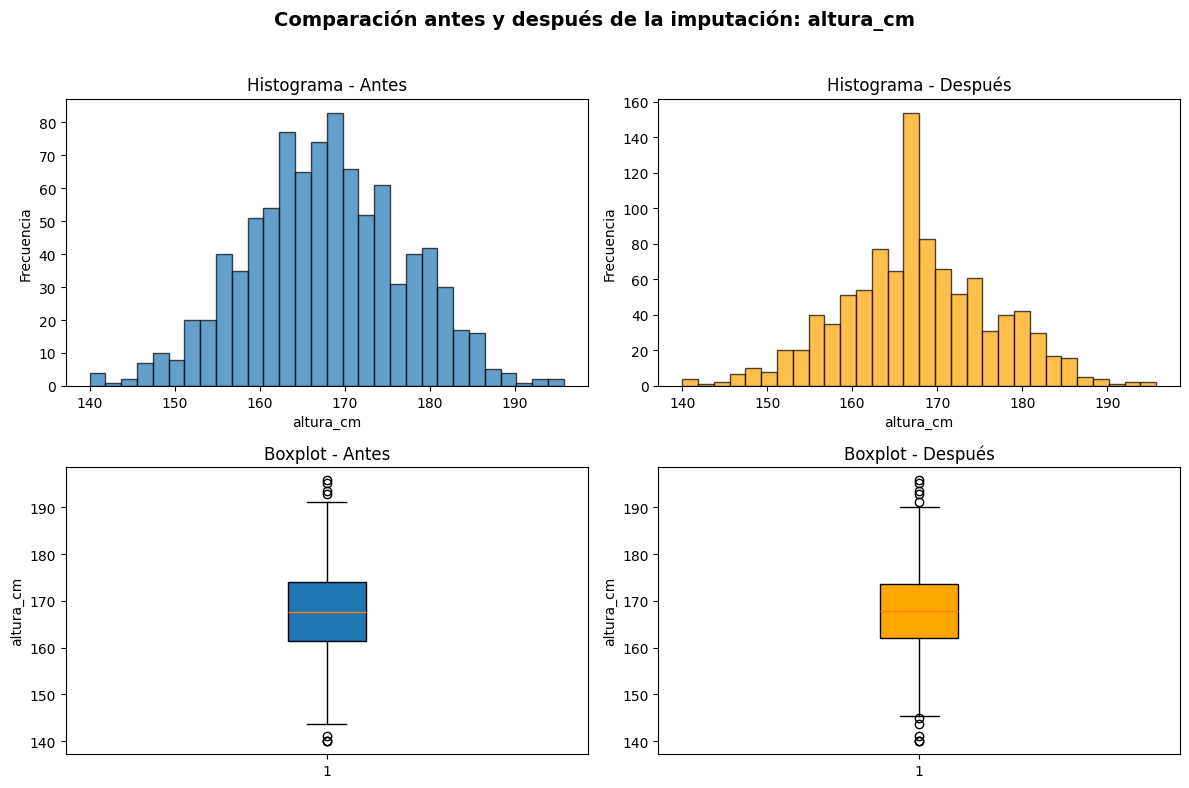

In [21]:
comparar_imputacion(df,df_imputado_media,variable="altura_cm")

La imputación de datos en la variable "`altura_cm`" aparentemente ha mantenido la distribución normal original, conservando visualmente la misma forma y rango de valores (140-190 cm) en los histogramas comparativos. Sin embargo, debemos confirmar la efectividad de la imputación mediante pruebas analíticas específicas.

##### **`Ingresos`**

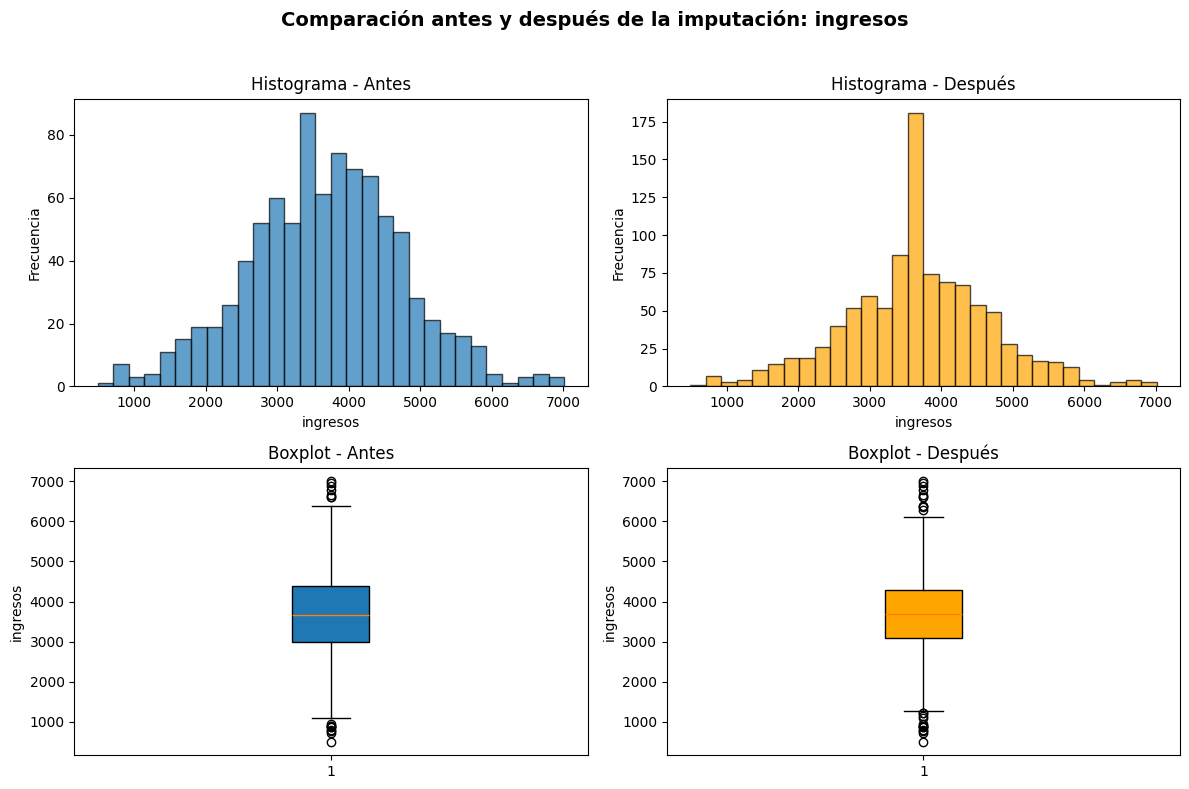

In [22]:
comparar_imputacion(df,df_imputado_media,variable="ingresos")

La imputación de datos en la variable "`ingresos`" aparentemente ha alterado la distribución original, observándose cambios significativos en la forma de los histogramas comparativos. Sin embargo, debemos confirmar la efectividad y posibles distorsiones de la imputación mediante pruebas analíticas.

##### **`gasto_mensual`:**

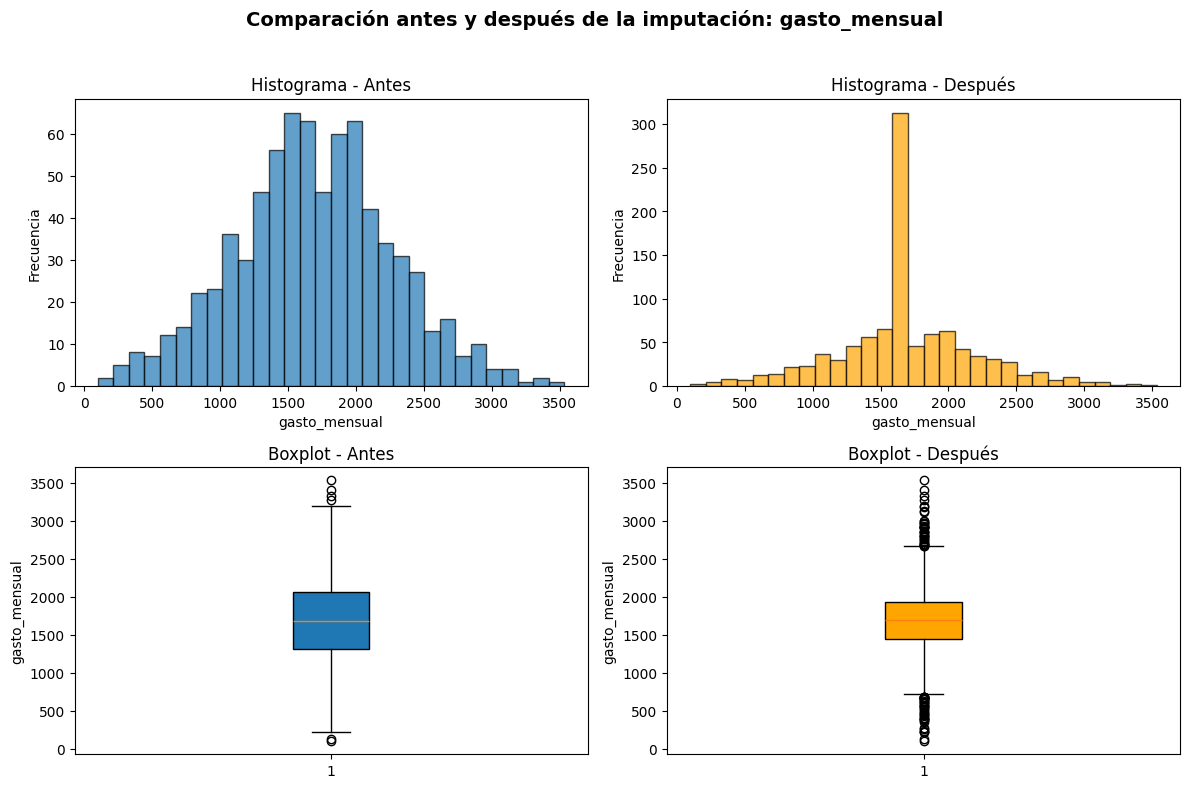

In [23]:
comparar_imputacion(df,df_imputado_media,variable="gasto_mensual")

La comparación entre los histogramas y boxplots de la variable gasto_mensual antes y después de la imputación evidencia un cambio importante en la distribución de los datos. Antes de la imputación, la variable presentaba una distribución aproximadamente simétrica, con una dispersión amplia y presencia de valores atípicos en ambos extremos. Sin embargo, tras la imputación, se observa una concentración excesiva de valores en torno a la media o mediana (alrededor de 1700), lo que genera un pico artificial en el histograma y un bloque central muy marcado en el boxplot.

##### **`puntuacion_credito`:**

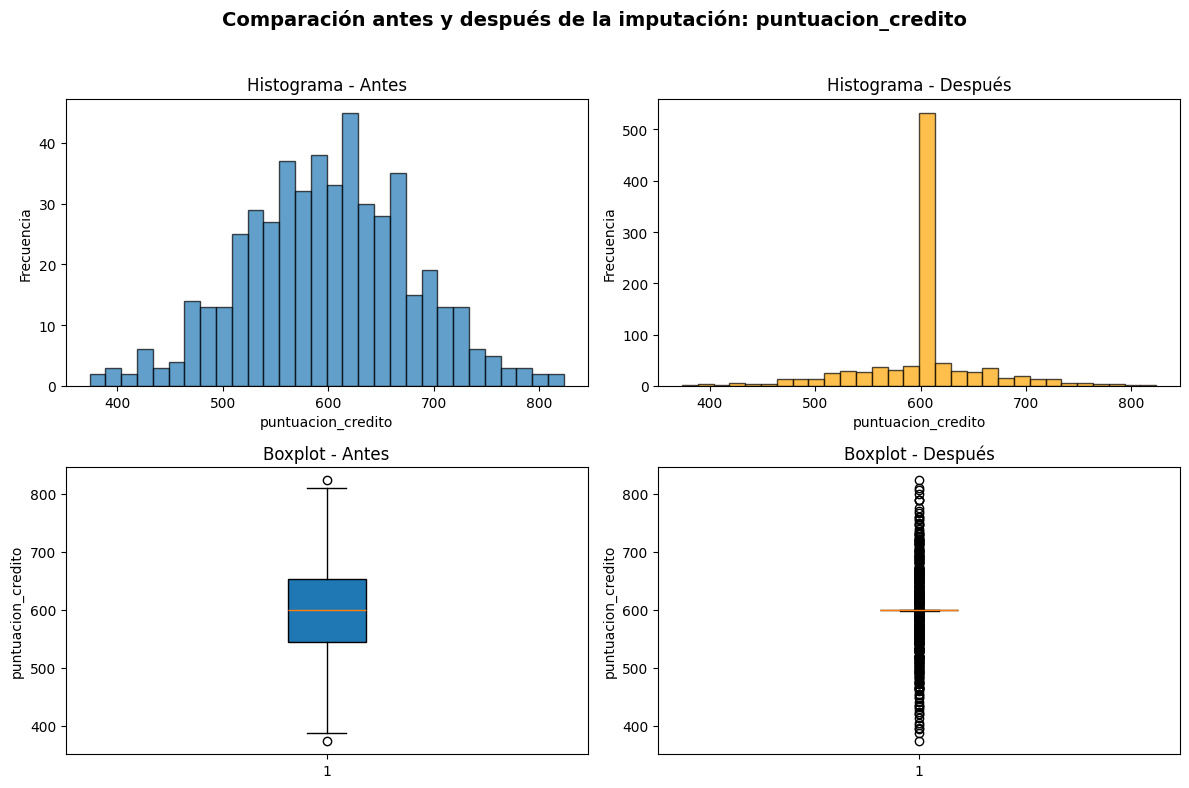

In [24]:
comparar_imputacion(df,df_imputado_media,variable="puntuacion_credito")

La variable puntuación_crédito muestra un cambio drástico tras la imputación. Antes de imputar, los datos presentaban una distribución aproximadamente normal, con valores concentrados entre 500 y 700, dispersión moderada y algunos valores extremos hacia los límites inferior y superior. Sin embargo, después de la imputación se observa un fuerte pico alrededor de 600.Esta concentración excesiva genera una pérdida significativa de variabilidad, distorsiona la distribución original y provoca una acumulación de outliers en el boxplot.

##### **Prueba Normalidad:**

In [25]:
prueba_normalidad(df_imputado_media,col_num_norm)

Resultados de la prueba de Shapiro-Wilk:

Variable: altura_cm            | Estadístico: 0.9954 | p-valor: 4.4792e-03 | No Normal
Variable: ingresos             | Estadístico: 0.9898 | p-valor: 1.9520e-06 | No Normal
Variable: gasto_mensual        | Estadístico: 0.9644 | p-valor: 6.5403e-15 | No Normal
Variable: puntuacion_credito   | Estadístico: 0.8566 | p-valor: 3.3681e-29 | No Normal

Interpretación: p < 0.05 → No normal | p ≥ 0.05 → Normal


Tras aplicar la imputación por la media, las variables que originalmente seguían una distribución normal dejaron de cumplir con este supuesto según la prueba de Shapiro–Wilk. En todos los casos, los valores de p fueron inferiores a 0.05 (altura_cm: 0.0045; ingresos: 0.0000019; gasto_mensual: 6.5e-15; puntuación_crédito: 3.3e-29), lo que indica que la hipótesis nula de normalidad se rechaza. Esto confirma que la imputación con la media, aunque efectiva para completar los valores faltantes, distorsionó significativamente la distribución original de las variables, reduciendo su variabilidad y concentrando los datos en torno a un valor central.

##### **Prueba Igualdad de Distribuciones:**

In [26]:
prueba_ks(df,df_imputado_media,col_num_norm)

Resultados de Kolmogorov-Smirnov (KS test):

Variable: altura_cm            | KS Estadístico: 0.0402 | p-valor: 4.0795e-01 | Distribuciones Iguales
Variable: ingresos             | KS Estadístico: 0.0603 | p-valor: 6.3341e-02 | Distribuciones Iguales
Variable: gasto_mensual        | KS Estadístico: 0.1270 | p-valor: 1.7856e-06 | Distribuciones Diferentes
Variable: puntuacion_credito   | KS Estadístico: 0.2520 | p-valor: 4.9757e-19 | Distribuciones Diferentes

Interpretación: p < 0.05 → Distribuciones diferentes | p ≥ 0.05 → Distribuciones iguales


Tras aplicar la imputación por la media, se evaluó la igualdad de distribuciones mediante la prueba de Kolmogorov–Smirnov. Los resultados muestran que las variables altura_cm (p = 0.408) e ingresos (p = 0.063) no presentan diferencias estadísticamente significativas respecto a su distribución original, por lo que se concluye que mantienen una estructura similar después de la imputación. En contraste, las variables gasto_mensual (p = 1.78e-06) y puntuación_crédito (p = 4.97e-19) evidencian diferencias significativas en su distribución, lo cual confirma que la imputación alteró de manera considerable su comportamiento original, concentrando valores en torno a la media y reduciendo la variabilidad natural. En síntesis, aunque la imputación por la media permitió completar los valores faltantes, generó un sesgo importante en ciertas variables, lo que limita la validez de análisis posteriores basados en sus distribuciones.

##### **Comparación de Medias:**

In [27]:
comparar_tstudent(df,df_imputado_media,col_num_norm)

Comparación de medias con T de Student:

Variable: altura_cm            | Estadístico: 0.0000 | p-valor: 1.0000e+00 | No hay diferencia significativa
Variable: ingresos             | Estadístico: 0.0000 | p-valor: 1.0000e+00 | No hay diferencia significativa
Variable: gasto_mensual        | Estadístico: -0.0000 | p-valor: 1.0000e+00 | No hay diferencia significativa
Variable: puntuacion_credito   | Estadístico: -0.0000 | p-valor: 1.0000e+00 | No hay diferencia significativa

Interpretación: p < 0.05 → diferencia significativa | p ≥ 0.05 → no significativa


Los resultados de la prueba t de Student para la comparación de medias entre los datos originales y los imputados muestran que en todas las variables (altura_cm, ingresos, gasto_mensual y puntuación_crédito) los valores de p fueron iguales a 1.0, lo que indica que no existen diferencias estadísticamente significativas en las medias después de la imputación. Esto significa que, aunque la imputación por la media alteró la forma de la distribución y redujo la variabilidad de algunas variables, logró mantener estable el valor promedio de cada una de ellas.

##### **Conclusiones:**

De acuerdo con los resultados obtenidos en las diferentes pruebas, la imputación por la media no puede considerarse un método adecuado. Si bien la prueba t de Student evidenció que las medias originales se conservaron (p = 1.0 en todas las variables), lo que garantiza que el valor promedio no se vio afectado, las pruebas de normalidad (Shapiro–Wilk) y de igualdad de distribuciones (Kolmogorov–Smirnov) demostraron que la forma y la variabilidad de los datos sí se alteraron de manera significativa. Esto es especialmente relevante dado que, inicialmente, todas las variables presentaban una distribución normal y, tras la imputación, el test de Shapiro–Wilk indicó que este supuesto ya no se cumplía. De manera similar, la prueba de Kolmogorov–Smirnov mostró que dos variables perdieron su distribución original. En consecuencia, la imputación por la media no resulta una opción adecuada en este caso.

#### **5.2.1.2. Regresión:**

In [28]:
# Crear imputador basado en regresión lineal
imputer = IterativeImputer(estimator=LinearRegression(), random_state=42)

# Ajustar y transformar solo las columnas seleccionadas
df_imputado_regre = df.copy()
df_imputado_regre[col_num_norm] = imputer.fit_transform(df[col_num_norm])

c:\Users\Usuario\miniconda3\envs\DataViz_venv\lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


##### **`Altura_cm:`**

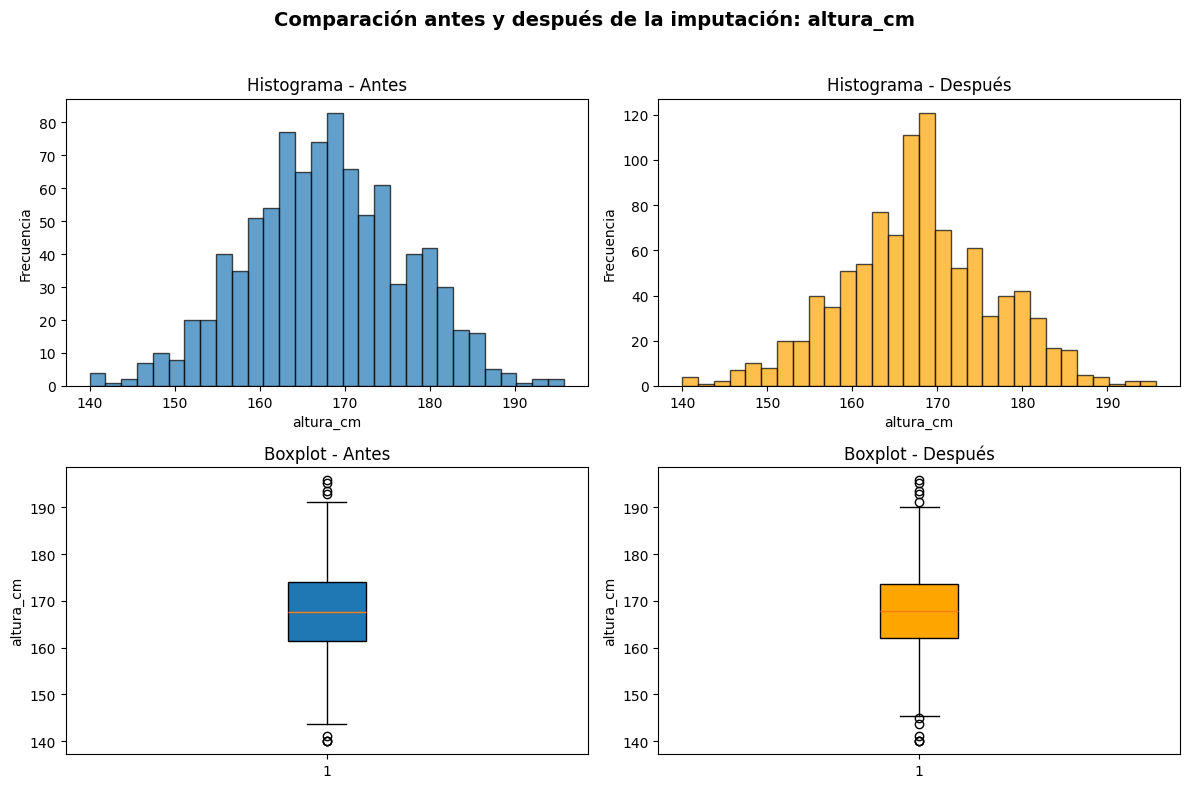

In [29]:
comparar_imputacion(df,df_imputado_regre,variable="altura_cm")

En la variable altura_cm, la imputación mediante regresión permitió conservar de manera más fiel la forma y la dispersión de la distribución original. Al comparar los histogramas, se observa que la distribución después de la imputación mantiene su simetría y su concentración central en torno a 165–170 cm, sin generar picos artificiales.De igual forma, los boxplots muestran que la mediana y el rango intercuartílico permanecen prácticamente inalterados, mientras que los valores atípicos se mantienen en proporciones similares antes y después del proceso. Esto indica que la imputación por regresión preserva tanto la tendencia central como la variabilidad natural de los datos.

##### **`Ingresos`:**

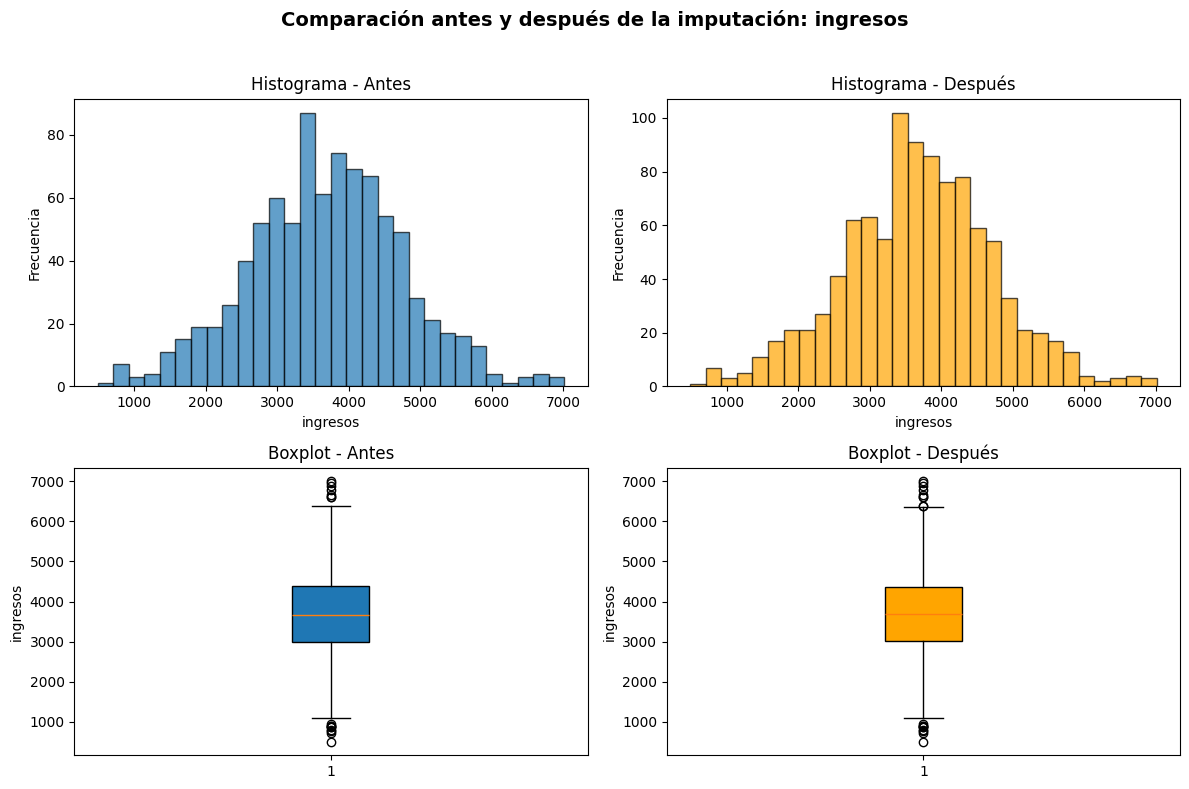

In [30]:
comparar_imputacion(df,df_imputado_regre,variable="ingresos")

En la variable ingresos, la imputación mediante regresión permitió mantener la forma general de la distribución original sin generar concentraciones artificiales en un valor específico. Los histogramas muestran que tanto antes como después de la imputación la variable conserva una distribución aproximadamente simétrica, centrada entre 3000 y 4000, con una dispersión amplia y colas que se extienden hasta valores bajos y altos. De igual manera, los boxplots reflejan que la mediana, el rango intercuartílico y la presencia de valores atípicos se mantienen prácticamente inalterados, lo que indica que la imputación preservó tanto la tendencia central como la variabilidad natural de los datos.

##### **`gasto_mensual`:**

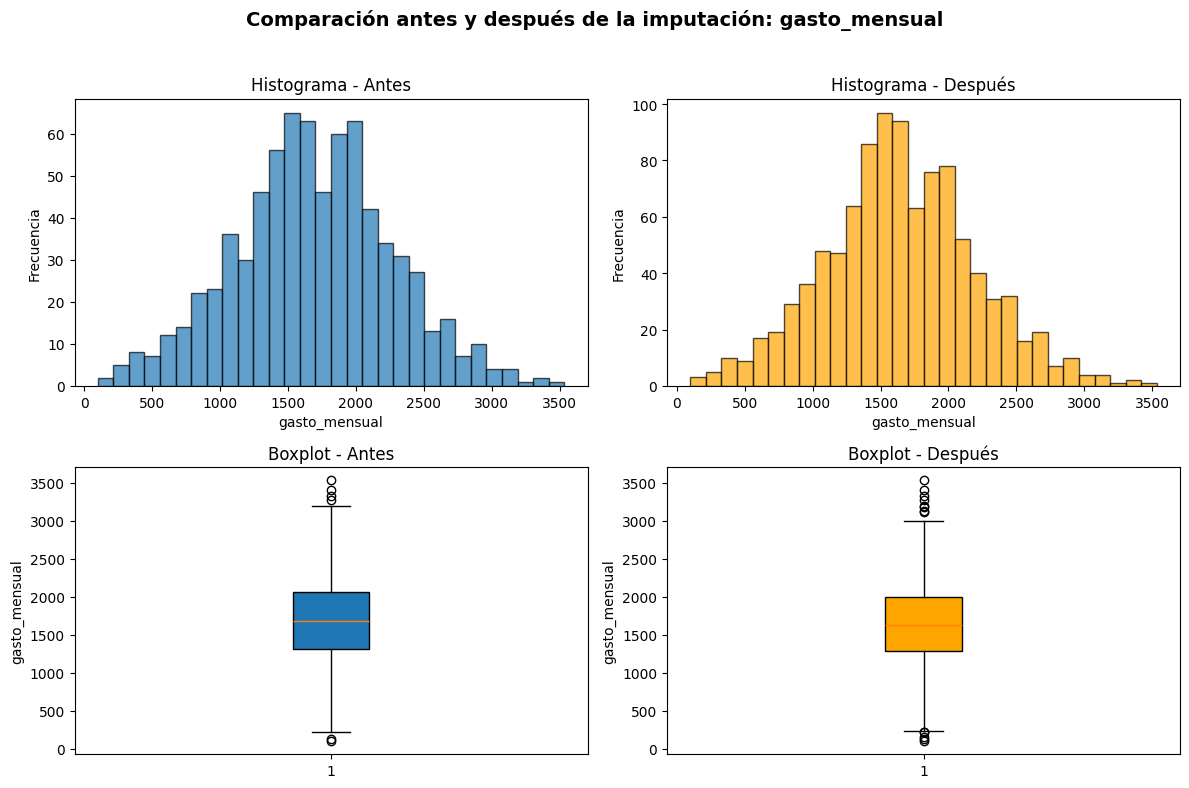

In [31]:
comparar_imputacion(df,df_imputado_regre,variable="gasto_mensual")

En la variable gasto_mensual, la imputación con regresión mantuvo de manera adecuada la forma de la distribución original, como se aprecia en los histogramas, donde el patrón sigue siendo aproximadamente simétrico y centrado entre 1500 y 2000, aunque con un ligero incremento en la concentración de valores alrededor de la media. Los boxplots muestran que tanto la mediana como el rango intercuartílico permanecen prácticamente estables después de la imputación, y los valores atípicos en las colas también se conservan, lo que indica que el método no eliminó la variabilidad extrema del conjunto de datos.

##### **`puntuacion_credito`:**

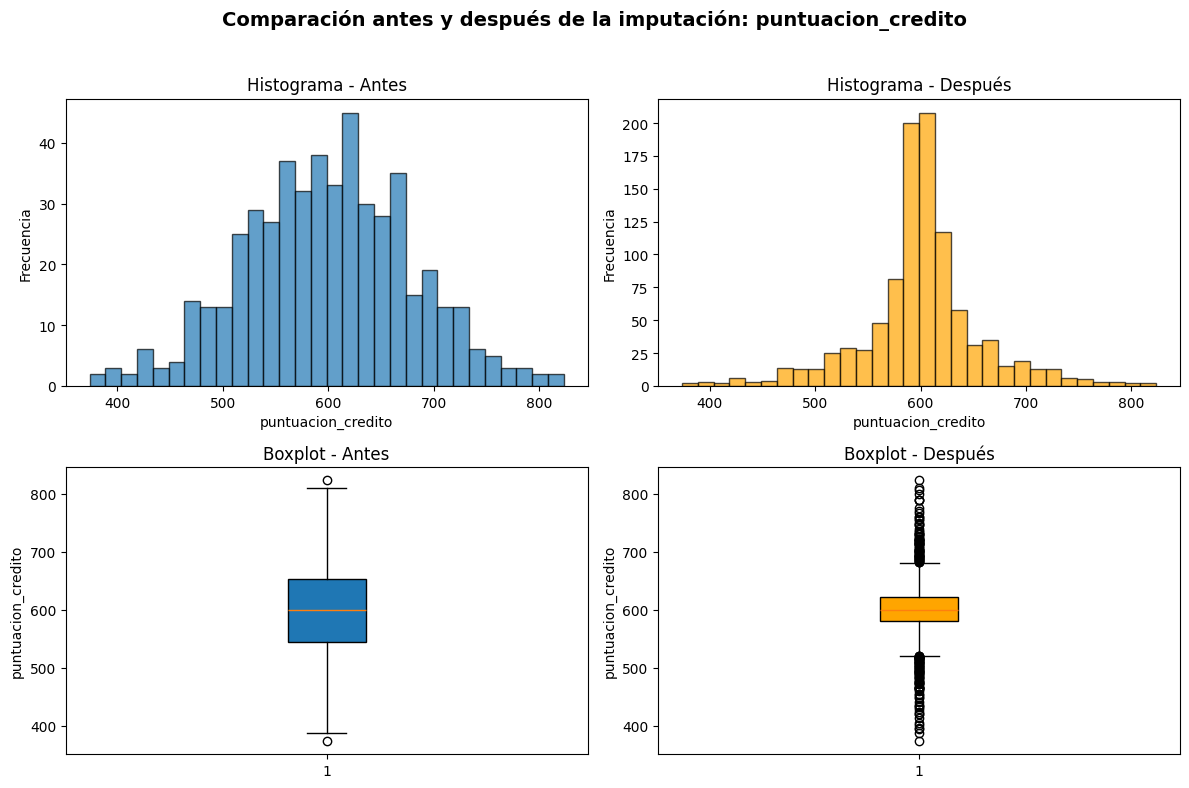

In [32]:
comparar_imputacion(df,df_imputado_regre,variable="puntuacion_credito")

En la variable puntuación_credito, la imputación mediante regresión modificó de manera notable la distribución de los datos. Antes de la imputación, el histograma mostraba una dispersión amplia con valores distribuidos de forma más uniforme y un rango extendido entre 400 y 800 puntos, mientras que después se observa una fuerte concentración alrededor de la media (≈600), reduciendo la variabilidad original. El boxplot confirma este efecto: aunque la mediana se conserva, la dispersión se reduce y aparecen múltiples valores repetidos en los extremos que se reflejan como gran cantidad de atípicos.

##### **Prueba Normalidad:**

In [33]:
prueba_normalidad(df_imputado_regre,col_num_norm)

Resultados de la prueba de Shapiro-Wilk:

Variable: altura_cm            | Estadístico: 0.9965 | p-valor: 2.3030e-02 | No Normal
Variable: ingresos             | Estadístico: 0.9971 | p-valor: 6.3426e-02 | Normal
Variable: gasto_mensual        | Estadístico: 0.9975 | p-valor: 1.3246e-01 | Normal
Variable: puntuacion_credito   | Estadístico: 0.9340 | p-valor: 1.2892e-20 | No Normal

Interpretación: p < 0.05 → No normal | p ≥ 0.05 → Normal


Los resultados de la prueba de normalidad Shapiro–Wilk aplicados después de la imputación muestran que no todas las variables conservaron la distribución normal que tenían originalmente. En particular, altura_cm (p = 0.023) y puntuacion_credito (p ≈ 0.000) presentan una desviación significativa de la normalidad, indicando que la imputación alteró de forma importante la forma de su distribución. En contraste, las variables ingresos (p = 0.063) y gasto_mensual (p = 0.132) mantuvieron la normalidad estadísticamente, lo que sugiere que la imputación no distorsionó de manera crítica sus distribuciones. En conjunto, los resultados evidencian que el método de imputación aplicado no logró preservar de manera uniforme la normalidad de todas las variables, afectando especialmente a aquellas con mayor sensibilidad en su forma y dispersión.

##### **Prueba Igualdad de Distribuciones:**

In [34]:
prueba_ks(df,df_imputado_regre,col_num_norm)

Resultados de Kolmogorov-Smirnov (KS test):

Variable: altura_cm            | KS Estadístico: 0.0328 | p-valor: 6.6549e-01 | Distribuciones Iguales
Variable: ingresos             | KS Estadístico: 0.0185 | p-valor: 9.9606e-01 | Distribuciones Iguales
Variable: gasto_mensual        | KS Estadístico: 0.0500 | p-valor: 2.2761e-01 | Distribuciones Iguales
Variable: puntuacion_credito   | KS Estadístico: 0.1720 | p-valor: 4.7972e-09 | Distribuciones Diferentes

Interpretación: p < 0.05 → Distribuciones diferentes | p ≥ 0.05 → Distribuciones iguales


Los resultados de la prueba de Kolmogorov-Smirnov indican que, tras la imputación, las variables altura_cm, ingresos y gasto_mensual conservaron distribuciones estadísticamente iguales a las originales (p > 0.05 en todos los casos), lo que sugiere que el método aplicado preservó de manera adecuada su forma y comportamiento global. Sin embargo, en el caso de puntuacion_credito (p < 0.001), se observa una diferencia significativa entre la distribución original y la imputada, lo que evidencia que este atributo fue el más afectado por el proceso de imputación y perdió su distribución inicial.

##### **Comparación de Medias:**

In [35]:
comparar_tstudent(df,df_imputado_regre,col_num_norm)

Comparación de medias con T de Student:

Variable: altura_cm            | Estadístico: -0.0320 | p-valor: 9.7449e-01 | No hay diferencia significativa
Variable: ingresos             | Estadístico: -0.1099 | p-valor: 9.1253e-01 | No hay diferencia significativa
Variable: gasto_mensual        | Estadístico: 1.6064 | p-valor: 1.0839e-01 | No hay diferencia significativa
Variable: puntuacion_credito   | Estadístico: -0.3064 | p-valor: 7.5940e-01 | No hay diferencia significativa

Interpretación: p < 0.05 → diferencia significativa | p ≥ 0.05 → no significativa


Los resultados de la prueba t de Student muestran que, tras la imputación, no existen diferencias estadísticamente significativas en las medias de ninguna de las variables analizadas (altura_cm, ingresos, gasto_mensual y puntuacion_credito), ya que en todos los casos el valor p fue mayor a 0.05. Esto indica que el procedimiento de imputación logró conservar los valores promedio originales de las variables, evitando sesgos en la tendencia central de los datos.

##### **Conclusiones:**

En términos generales, la imputación por regresión mostró un mejor desempeño que la imputación por la media, ya que logró conservar las medias originales y, en la mayoría de los casos, mantuvo la forma de las distribuciones sin alteraciones significativas, especialmente en las variables ingresos y gasto_mensual, que conservaron tanto su tendencia central como su distribución global. Sin embargo, los resultados también evidencian limitaciones: en altura_cm la normalidad se perdió levemente tras la imputación (aunque la distribución general se mantuvo), y en puntuacion_credito el impacto fue más marcado, con pérdida de normalidad y diferencias significativas en la forma de la distribución, como también lo reflejan los histogramas y boxplots. Por tanto, la imputación por regresión puede considerarse recomendable para variables como ingresos y gasto_mensual, donde demostró ser consistente y confiable, mientras que para puntuacion_credito no resulta adecuada, ya que introduce distorsiones notorias en la estructura de los datos.

#### **5.2.1.3. KNN:**

In [36]:

# Crear copia del DataFrame original
df_imputado_knn = df.copy()

# Inicializar el imputador KNN
imputer = KNNImputer(n_neighbors=5)  # puedes ajustar n_neighbors

# Ajustar e imputar solo las columnas seleccionadas
df_imputado_knn[col_num_norm] = imputer.fit_transform(df[col_num_norm])

##### **`Altura_cm:`**

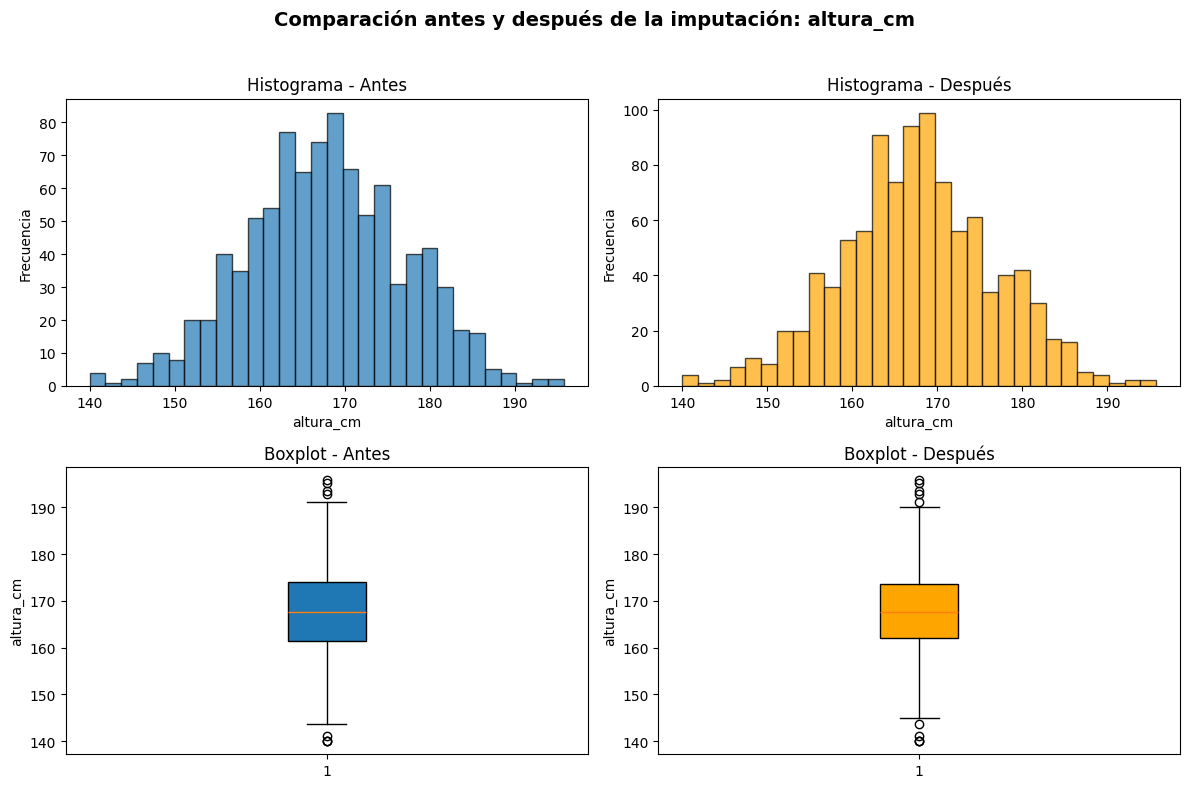

In [37]:
comparar_imputacion(df,df_imputado_knn,variable="altura_cm")

La imputación mediante KNN permitió conservar de manera adecuada la forma general de la distribución, como se observa en los histogramas antes y después, donde la simetría y la dispersión de los datos se mantienen sin cambios significativos. Asimismo, en los boxplots se aprecia que la mediana, los rangos intercuartílicos y los valores atípicos permanecen prácticamente estables, lo que indica que la técnica no introdujo sesgos notorios ni distorsiones en la estructura original de los datos.

##### **`Ingresos`:**

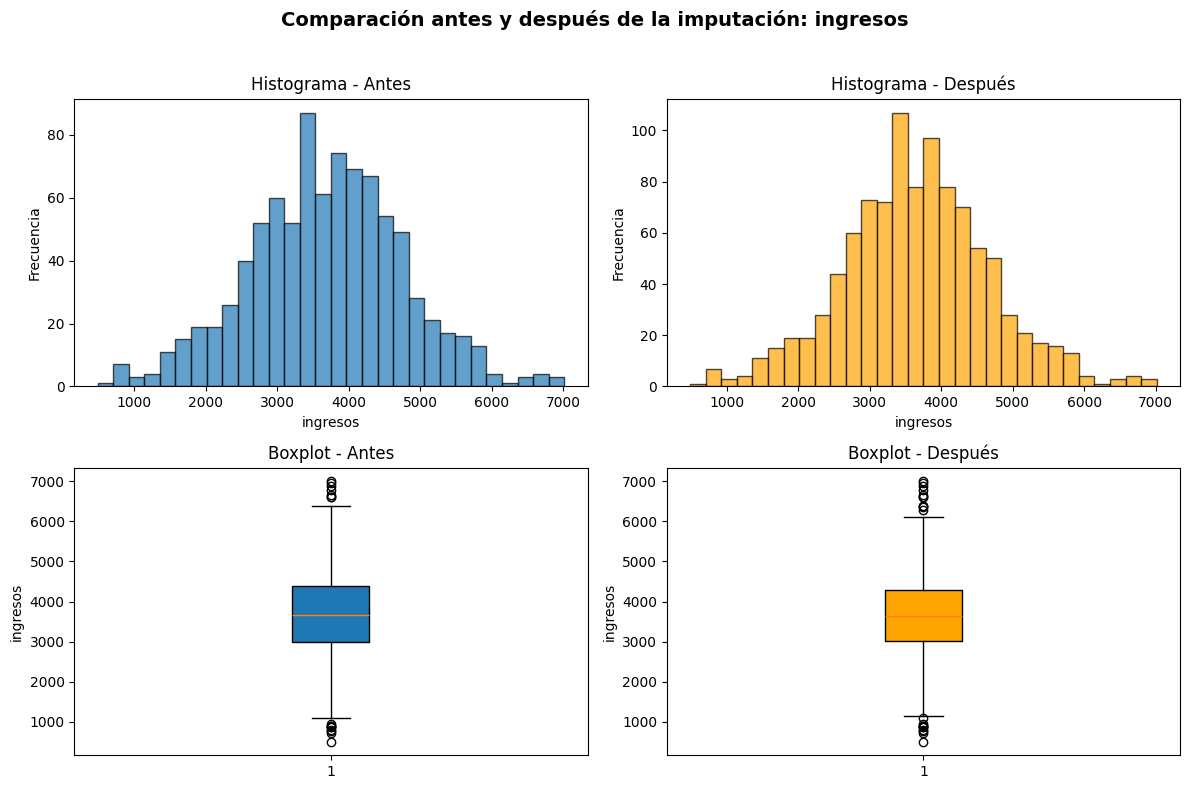

In [38]:
comparar_imputacion(df,df_imputado_knn,variable="ingresos")

La imputación realizada mediante KNN mantuvo de manera consistente la forma de la distribución original, tal como se observa en los histogramas, donde la simetría y la dispersión apenas presentan cambios perceptibles entre el antes y el después. Asimismo, en los boxplots se aprecia que la mediana, el rango intercuartílico y los valores atípicos se conservaron, lo que indica que el método no distorsionó la estructura ni la variabilidad de los datos.

##### **`gasto_mensual`:**

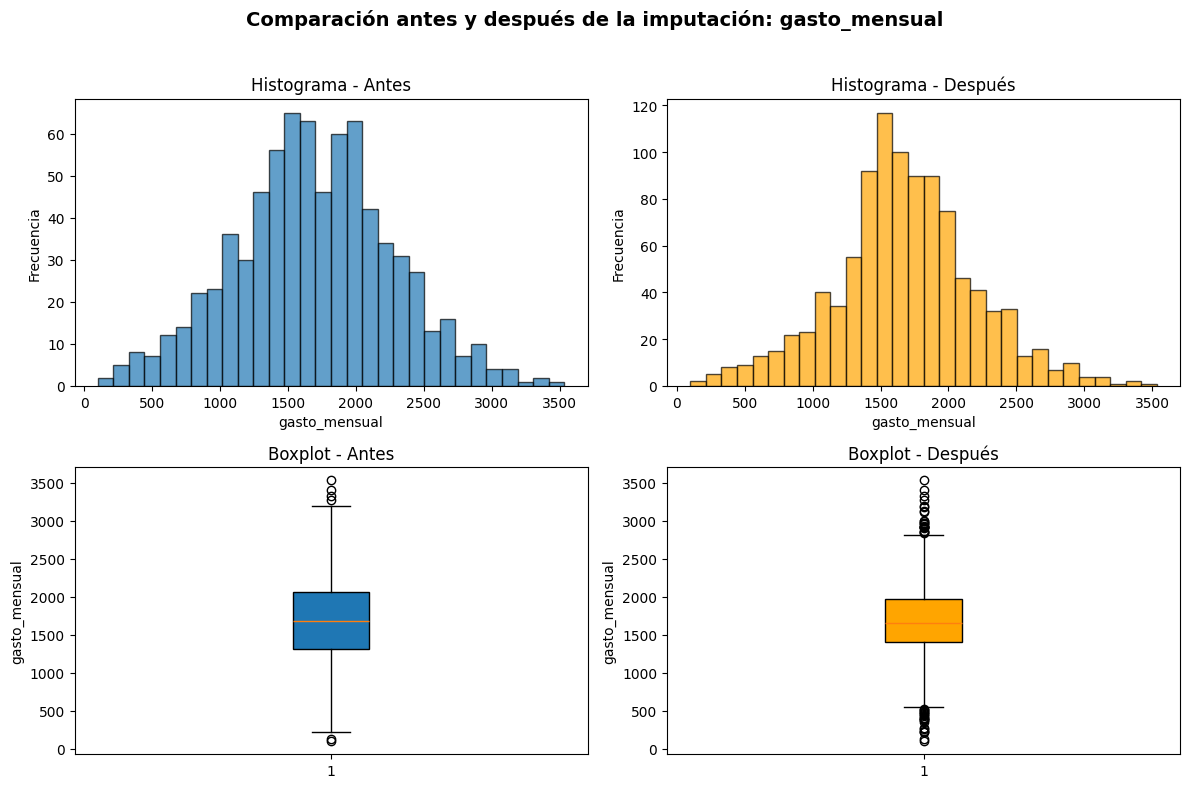

In [39]:
comparar_imputacion(df,df_imputado_knn,variable="gasto_mensual")

Los histogramas muestran que la forma general de la distribución se mantuvo después de la imputación, conservando la simetría y la dispersión de los datos, aunque se observa un ligero aumento en la concentración alrededor de la media. En los boxplots se aprecia que la mediana y el rango intercuartílico permanecen estables, pero se generó un mayor número de valores atípicos tanto en los extremos bajos como en los altos, lo que indica que el método introdujo cierta variabilidad adicional.

##### **`puntuacion_credito`:**

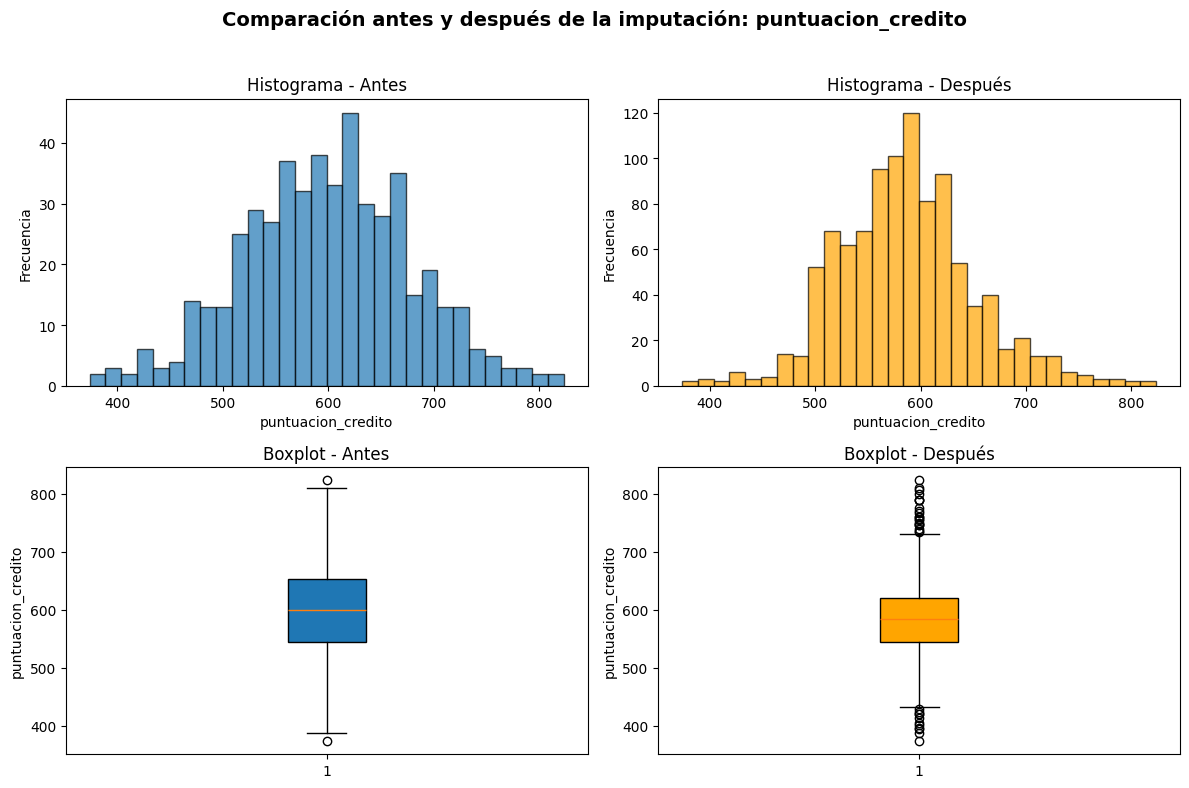

In [40]:
comparar_imputacion(df,df_imputado_knn,variable="puntuacion_credito")

Los histogramas muestran que tras la imputación se mantuvo la distribución general con un comportamiento aproximadamente normal, aunque la concentración de valores en torno a la media se hizo más marcada, reduciendo ligeramente la dispersión en los extremos. En los boxplots se observa que la mediana y el rango intercuartílico se conservaron, pero aumentó de forma notoria el número de valores atípicos, especialmente en los límites superior e inferior.

##### **Prueba Normalidad:**

In [41]:
prueba_normalidad(df_imputado_knn,col_num_norm)

Resultados de la prueba de Shapiro-Wilk:

Variable: altura_cm            | Estadístico: 0.9980 | p-valor: 2.7136e-01 | Normal
Variable: ingresos             | Estadístico: 0.9960 | p-valor: 1.1660e-02 | No Normal
Variable: gasto_mensual        | Estadístico: 0.9919 | p-valor: 2.8280e-05 | No Normal
Variable: puntuacion_credito   | Estadístico: 0.9883 | p-valor: 3.7032e-07 | No Normal

Interpretación: p < 0.05 → No normal | p ≥ 0.05 → Normal


Los resultados de la prueba de Shapiro-Wilk muestran que, tras la imputación, únicamente la variable altura_cm conserva un comportamiento consistente con la normalidad (p = 0.271 > 0.05), mientras que ingresos, gasto_mensual y puntuacion_credito presentan distribuciones que se desvían significativamente de la normalidad (p < 0.05).

##### **Prueba Igualdad de Distribuciones:**

In [42]:
prueba_ks(df,df_imputado_knn,col_num_norm)

Resultados de Kolmogorov-Smirnov (KS test):

Variable: altura_cm            | KS Estadístico: 0.0226 | p-valor: 9.6163e-01 | Distribuciones Iguales
Variable: ingresos             | KS Estadístico: 0.0367 | p-valor: 5.3887e-01 | Distribuciones Iguales
Variable: gasto_mensual        | KS Estadístico: 0.0603 | p-valor: 8.5225e-02 | Distribuciones Iguales
Variable: puntuacion_credito   | KS Estadístico: 0.1480 | p-valor: 8.4207e-07 | Distribuciones Diferentes

Interpretación: p < 0.05 → Distribuciones diferentes | p ≥ 0.05 → Distribuciones iguales


Los resultados de la prueba de Kolmogorov-Smirnov indican que la imputación mantuvo distribuciones estadísticamente equivalentes entre los datos originales y los imputados para altura_cm, ingresos y gasto_mensual (p > 0.05 en todos los casos), lo que sugiere que el procedimiento no alteró de manera significativa sus formas de distribución. Sin embargo, en puntuacion_credito se observa una diferencia significativa (p < 0.05), lo que revela que la imputación modificó de manera importante su distribución original, posiblemente acentuando concentraciones en torno a la media y generando un patrón distinto al observado antes de imputar.

##### **Comparación de Medias:**

In [43]:
comparar_tstudent(df,df_imputado_knn,col_num_norm)

Comparación de medias con T de Student:

Variable: altura_cm            | Estadístico: 0.1581 | p-valor: 8.7442e-01 | No hay diferencia significativa
Variable: ingresos             | Estadístico: 0.5715 | p-valor: 5.6774e-01 | No hay diferencia significativa
Variable: gasto_mensual        | Estadístico: 0.3672 | p-valor: 7.1354e-01 | No hay diferencia significativa
Variable: puntuacion_credito   | Estadístico: 3.1961 | p-valor: 1.4449e-03 | Diferencia significativa

Interpretación: p < 0.05 → diferencia significativa | p ≥ 0.05 → no significativa


Los resultados de la prueba T de Student muestran que, tras la imputación, no existen diferencias significativas en las medias de altura_cm, ingresos y gasto_mensual (p > 0.05), lo que indica que la imputación preservó adecuadamente los promedios originales de estas variables. En contraste, la variable puntuacion_credito sí presenta una diferencia significativa en su media (p < 0.05), lo que confirma que el proceso de imputación modificó de forma relevante su tendencia central.

##### **Conclusión:**

En conjunto, tanto las gráficas como las pruebas estadísticas permiten concluir que el método de imputación KNN resultó eficaz para la variables altura_cm, ya que después de la imputación esta mantienen una distribucion similar a la original, sin cambios significativos en su media y con un comportamiento visual coherente en histogramas y boxplots. En cambio, para las variables  puntuacion_credito, ingresos y gasto mensual, el método no fue adecuado: las pruebas muestran cambios en la normalidad de las distribuciones, en puntuación_credito diferencias significativas en su media y distribución, además de una mayor concentración artificial alrededor de ciertos valores, lo que indica pérdida de representatividad.

### **5.2.2. Numéricas No Normales:**

#### **5.2.2.1. Mediana:**

In [44]:
df_imputado_anorm_median = df.copy()

# Imputar NaN con la mediana
for col in col_num_NoNorm:
    mediana = df[col].median()
    df_imputado_anorm_median[col] = df[col].fillna(mediana)

##### **`edad`:**

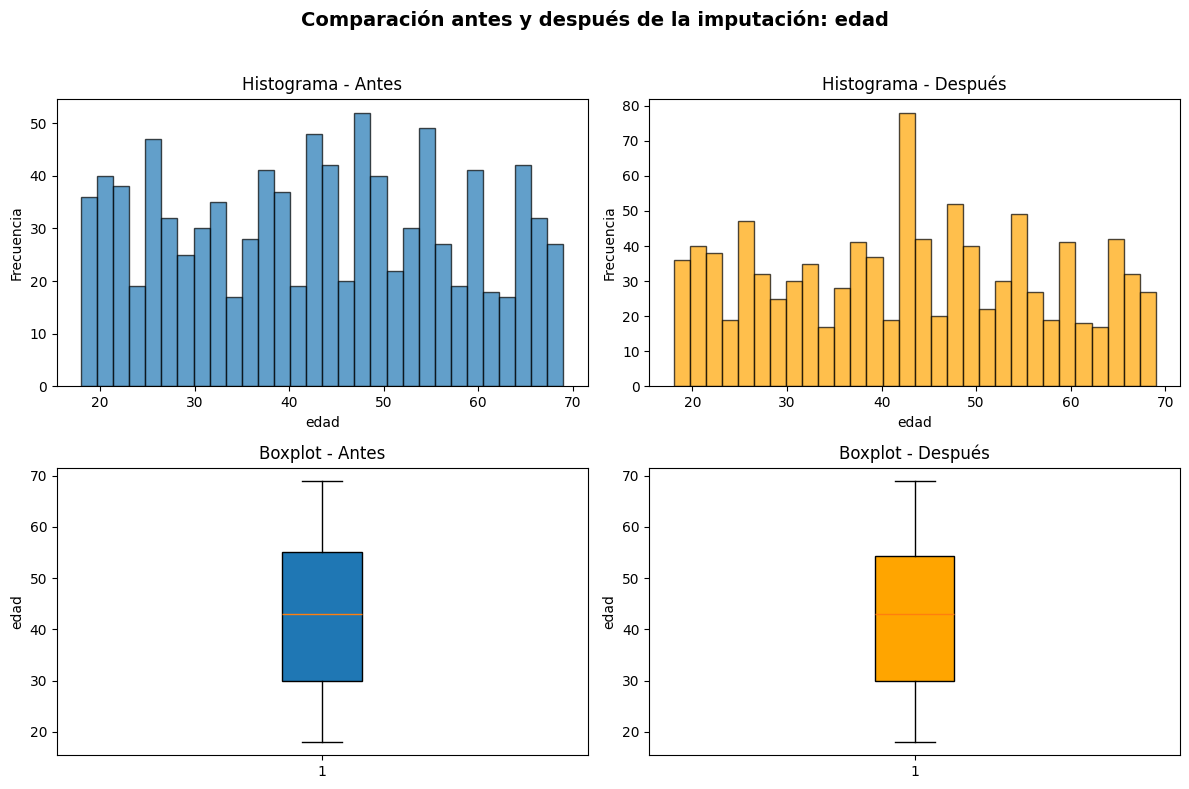

In [45]:
comparar_imputacion(df,df_imputado_anorm_median,"edad")

En los histogramas se observa que, tras la imputación, hay un aumento notable en la frecuencia de la mediana, lo que indica que los valores faltantes fueron reemplazados por este valor central. A pesar de este pico artificial, la forma general de la distribución se mantiene. En los boxplots, la mediana y la dispersión son muy similares antes y después de la imputación, lo que sugiere que el procedimiento no alteró significativamente la variabilidad de los datos.

##### **`demanda`:**

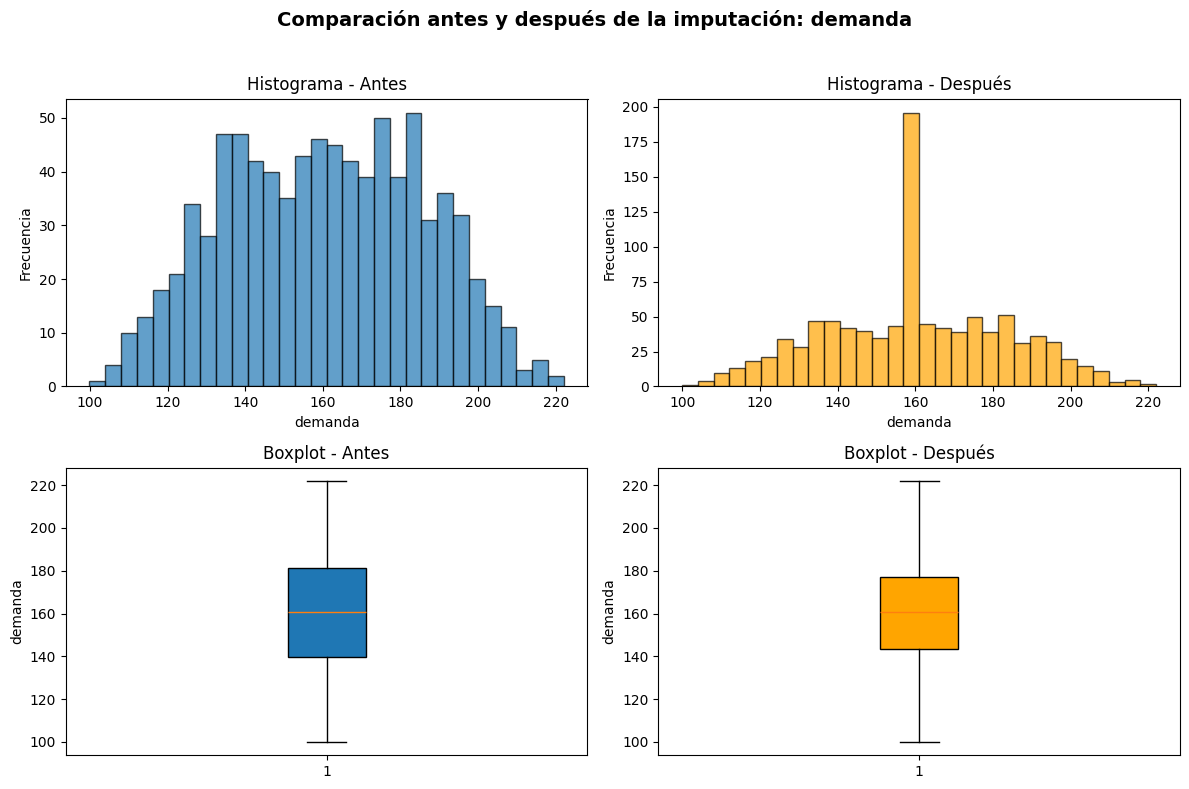

In [46]:
comparar_imputacion(df,df_imputado_anorm_median,"demanda")

En el histograma original, la distribución es aproximadamente simétrica y cercana a una normal, lo que sugiere una buena dispersión de los datos sin sesgos importantes. Tras la imputación, se observa un pico muy pronunciado en torno al valor de la mediana, reflejo de que numerosos valores faltantes fueron reemplazados por este valor central. Aunque esto introduce una distorsión visual clara en la distribución, el boxplot muestra que la mediana y la dispersión general se mantienen prácticamente iguales, lo que indica que la imputación no alteró de forma significativa las características globales de la variable.

##### **Prueba Normalidad:**

In [47]:
prueba_normalidad(df_imputado_anorm_median,col_num_NoNorm)

Resultados de la prueba de Shapiro-Wilk:

Variable: edad                 | Estadístico: 0.9635 | p-valor: 3.9251e-15 | No Normal
Variable: demanda              | Estadístico: 0.9888 | p-valor: 6.6051e-07 | No Normal

Interpretación: p < 0.05 → No normal | p ≥ 0.05 → Normal


Los resultados de la prueba de Shapiro-Wilk indican que tanto la variable edad como demanda no siguen una distribución normal, ya que en ambos casos el p-valor es menor a 0.05. Específicamente, la variable edad presenta un estadístico de 0.9635 y un p-valor extremadamente bajo (3.93e-15), lo que sugiere una fuerte desviación de la normalidad. Por su parte, demanda tiene un estadístico de 0.9888 y un p-valor de 6.60e-07, también menor a 0.05, aunque más cercano al umbral, lo que indica una menor pero aún significativa desviación de la normalidad.

##### **Prueba Igualdad de Distribuciones:**

In [48]:
prueba_ks(df,df_imputado_anorm_median,col_num_NoNorm)

Resultados de Kolmogorov-Smirnov (KS test):

Variable: edad                 | KS Estadístico: 0.0148 | p-valor: 9.9985e-01 | Distribuciones Iguales
Variable: demanda              | KS Estadístico: 0.0750 | p-valor: 1.0673e-02 | Distribuciones Diferentes

Interpretación: p < 0.05 → Distribuciones diferentes | p ≥ 0.05 → Distribuciones iguales


Para la variable edad, el p-valor es 0.99985 (muy superior a 0.05), lo que indica que no hay diferencias significativas entre ambas distribuciones; es decir, la imputación por mediana no alteró la forma general de la distribución. En cambio, para la variable demanda, el p-valor es 0.01067, menor al umbral de 0.05, lo que sugiere que la imputación sí modificó significativamente la distribución original. Esto concuerda con lo observado en el histograma de demanda, donde el valor de la mediana se ve claramente sobre-representado tras la imputación.

##### **Comparación de Medias:**

In [49]:
comparar_mannwhitney(df,df_imputado_anorm_median,col_num_NoNorm)

Comparación de distribuciones con Mann–Whitney U:

Variable: edad                 | Estadístico: 485075.0000 | p-valor: 9.9529e-01 | No hay diferencia significativa
Variable: demanda              | Estadístico: 425000.0000 | p-valor: 1.0000e+00 | No hay diferencia significativa

Interpretación: p < 0.05 → diferencia significativa | p ≥ 0.05 → no significativa


En el caso de edad, el p-valor es 0.99529, y para demanda, el p-valor es 1.0, ambos muy superiores al umbral de 0.05. Esto indica que, a pesar de que la imputación (especialmente en demanda) pudo haber alterado la forma de la distribución —como se evidenció en la prueba KS—, la tendencia central (mediana) se mantuvo sin cambios estadísticamente significativos. Por tanto, desde el punto de vista de la comparación de medianas, la imputación por mediana no introdujo sesgos relevantes.

#### **5.2.2.2. Regresión:**

In [50]:
# Crear imputador basado en regresión lineal
imputer = IterativeImputer(estimator=LinearRegression(), random_state=42)

# Ajustar y transformar solo las columnas seleccionadas
df_imputado_Anorm_regre = df.copy()
df_imputado_Anorm_regre[col_num_NoNorm] = imputer.fit_transform(df[col_num_NoNorm])

##### **`edad`:**

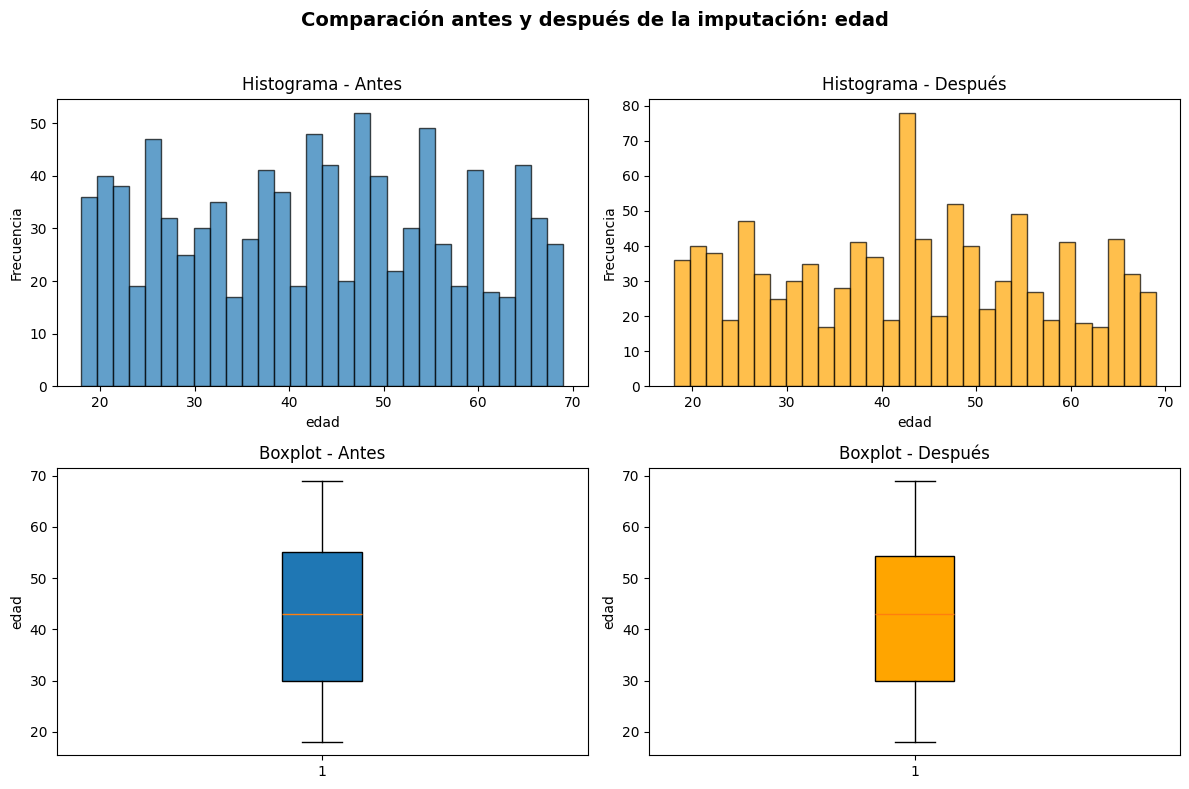

In [51]:
comparar_imputacion(df,df_imputado_Anorm_regre,"edad")

En el histograma, se observa que la distribución general de la variable se mantiene relativamente estable tras la imputación, sin un pico artificial marcado, lo que indica que la regresión logró generar valores coherentes con la tendencia de los datos originales. En los boxplots, la mediana, la dispersión y la forma de la caja se conservan casi sin cambios, lo que sugiere que la imputación por regresión no introdujo distorsiones significativas en la estructura de los datos.

##### **`demanda`**

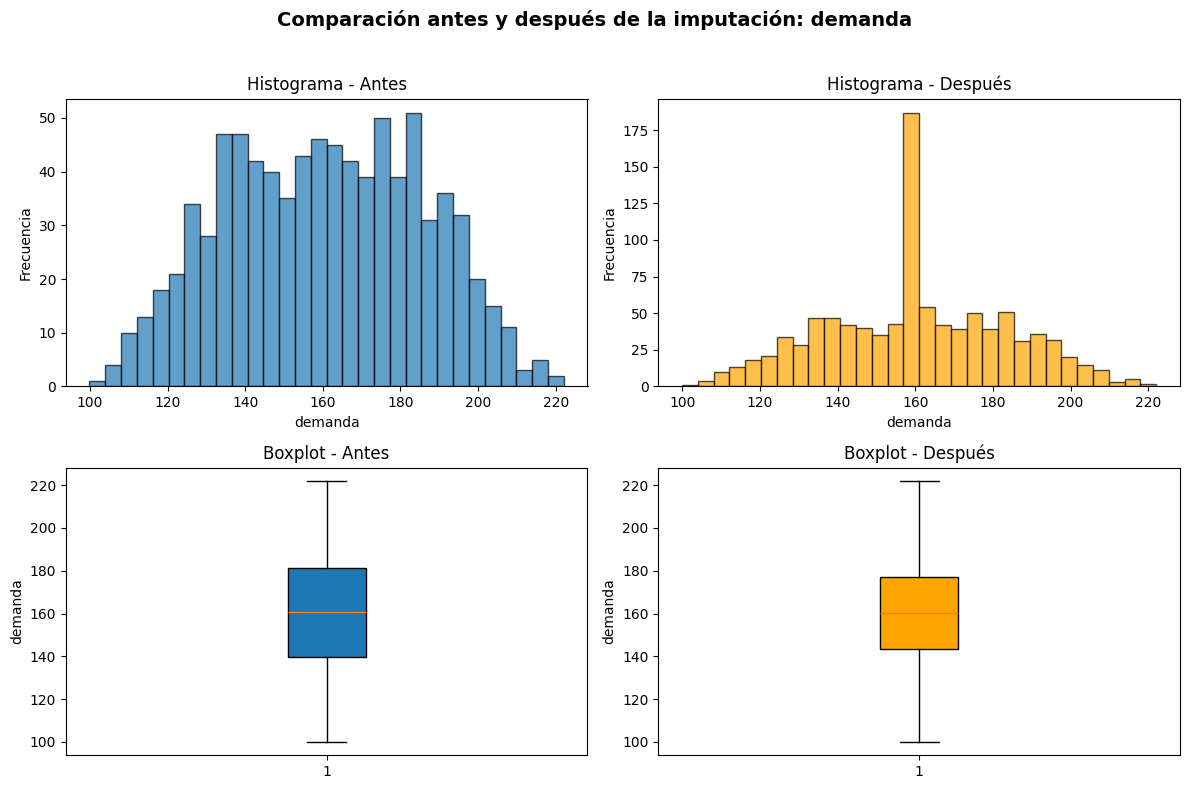

In [52]:
comparar_imputacion(df,df_imputado_Anorm_regre,"demanda")

En el histograma, se observa que después de la imputación la distribución de la variable demanda presenta una concentración marcada de valores alrededor de la media, lo que genera un pico evidente y una reducción de la dispersión respecto a los datos originales. En los boxplots, aunque de manera general no se aprecian cambios drásticos, un análisis más detallado muestra una compresión en la caja, lo cual coincide con lo observado en el histograma. Estos resultados sugieren que la imputación por regresión modificó la estructura de la distribución, aunque es necesario corroborar esta apreciación mediante pruebas analíticas que permitan determinar con mayor precisión la magnitud del cambio.

##### **Prueba Normalidad:**

In [53]:
prueba_normalidad(df_imputado_Anorm_regre,col_num_NoNorm)

Resultados de la prueba de Shapiro-Wilk:

Variable: edad                 | Estadístico: 0.9635 | p-valor: 4.0153e-15 | No Normal
Variable: demanda              | Estadístico: 0.9895 | p-valor: 1.4135e-06 | No Normal

Interpretación: p < 0.05 → No normal | p ≥ 0.05 → Normal


La prueba de Shapiro-Wilk nos revela que tanto la variable edad como la variable demanda presentan valores de p inferiores a 0.05, lo que indica que ninguna de las dos sigue una distribución normal. En el caso de la edad, el estadístico obtenido (0.9635), junto con un p-valor extremadamente pequeño, confirma un alejamiento significativo de la normalidad. De manera similar, la demanda, aunque con un estadístico más cercano a 1 (0.9895), también presenta un p-valor muy bajo, lo que refuerza la conclusión de que su distribución no puede considerarse normal. Este resultado es consistente con lo que ya se conocía de las variables antes de la imputación, por lo que, en términos de normalidad, no se han visto afectadas después del proceso de imputación.

##### **Prueba Igualdad de Distribuciones:**

In [54]:
prueba_ks(df,df_imputado_Anorm_regre,col_num_NoNorm)

Resultados de Kolmogorov-Smirnov (KS test):

Variable: edad                 | KS Estadístico: 0.0148 | p-valor: 9.9985e-01 | Distribuciones Iguales
Variable: demanda              | KS Estadístico: 0.0738 | p-valor: 1.2652e-02 | Distribuciones Diferentes

Interpretación: p < 0.05 → Distribuciones diferentes | p ≥ 0.05 → Distribuciones iguales


La prueba de Kolmogorov-Smirnov para la igualdad de distribuciones nos arroja que en el caso de la variable edad que presenta un estadistico de (0.0148) y un p-valor cercano a 1, lo cual indica que la distribución antes y despues de la imputación estadisticamente se consideran iguales. Por otro lado, la variable demanda muestra un estadistico de 0.0738 con un p-valor inferior a 0.05, lo que señala que la distribución si experimento cambios tras la imputación.

##### **Comparación de Medias:**

In [55]:
comparar_mannwhitney(df,df_imputado_Anorm_regre,col_num_NoNorm)

Comparación de distribuciones con Mann–Whitney U:

Variable: edad                 | Estadístico: 485170.0000 | p-valor: 9.8928e-01 | No hay diferencia significativa
Variable: demanda              | Estadístico: 425618.0000 | p-valor: 9.5699e-01 | No hay diferencia significativa

Interpretación: p < 0.05 → diferencia significativa | p ≥ 0.05 → no significativa


La prueba de comparación de medias mediante Mann-Whitney U arroja p-valores mayores a 0.05 para ambas variables, lo que permite concluir que no existen diferencias estadísticamente significativas entre las medias antes y después de la imputación. En el caso de la variable demanda, este resultado se relaciona con lo observado en los histogramas, donde tras la imputación se generó un pico alrededor de la media. En consecuencia, esta prueba respalda la conclusión de que, desde un punto de vista estadístico, no se presentan diferencias significativas después de la imputación.

##### **Conclusión:**

A partir de los resultados de las pruebas estadísticas y de lo observado en los gráficos, se puede concluir que el método de imputación por regresión presenta un desempeño mixto en cuanto a la preservación de las características originales de las variables. En el caso de la variable edad, tanto los histogramas como los boxplots muestran que la distribución se mantuvo estable, lo cual es consistente con los resultados de Kolmogorov-Smirnov y Mann-Whitney U, que indicaron ausencia de diferencias significativas. Esto sugiere que la imputación por regresión fue adecuada para esta variable. Sin embargo, en la variable demanda los histogramas revelaron una concentración artificial de valores alrededor de la media y los boxplots mostraron una compresión en la caja, lo que fue corroborado por la prueba de Kolmogorov-Smirnov, que señaló un cambio en la distribución tras la imputación. Aun así, la prueba de Mann-Whitney U no detectó diferencias significativas en términos estadísticos, lo que indica que, si bien la forma de la distribución se modificó, el comportamiento central de la variable no se alteró de manera sustancial. Esto nos permite afirmar que la imputación por regresión fue adecuada para la variable edad, mientras que para la demanda, no es un método adecuado dado los cambios inducidos.

#### **5.2.2.3. KNN:**

In [56]:

# Crear copia del DataFrame original
df_imputado_Anorm_knn = df.copy()

# Inicializar el imputador KNN
imputer = KNNImputer(n_neighbors=5)  # puedes ajustar n_neighbors

# Ajustar e imputar solo las columnas seleccionadas
df_imputado_Anorm_knn[col_num_NoNorm] = imputer.fit_transform(df[col_num_NoNorm])

##### **`Edad`:**

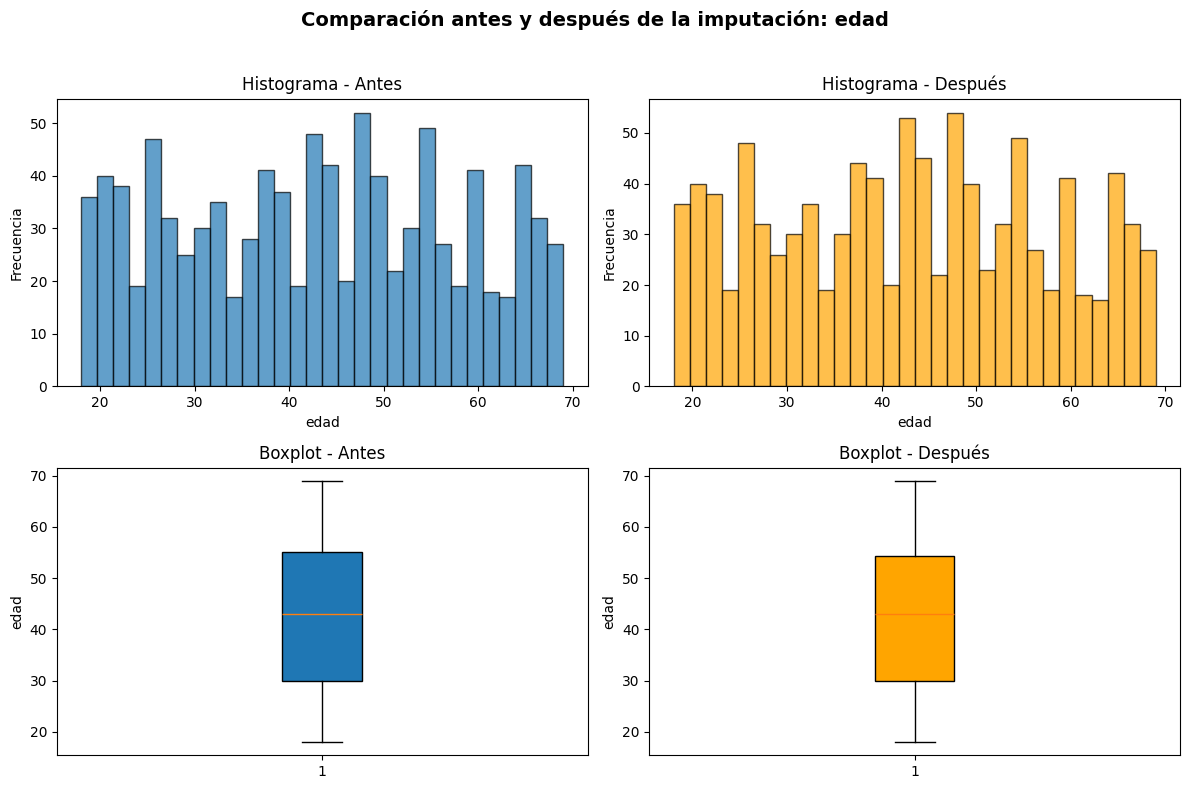

In [57]:
comparar_imputacion(df,df_imputado_Anorm_knn,variable="edad")

En el histograma, se observa que la distribución de la variable edad se mantiene prácticamente igual después de la imputación por KNN, sin la aparición de concentraciones artificiales ni cambios notorios en la forma general de la distribución, lo que indica que este método logró generar valores coherentes con los datos originales. En los boxplots, tanto la mediana como la dispersión y la forma de la caja se conservan de manera muy similar antes y después de la imputación, lo que sugiere que el método KNN no introdujo distorsiones significativas en la estructura de la variable.

##### **`demanda`:**

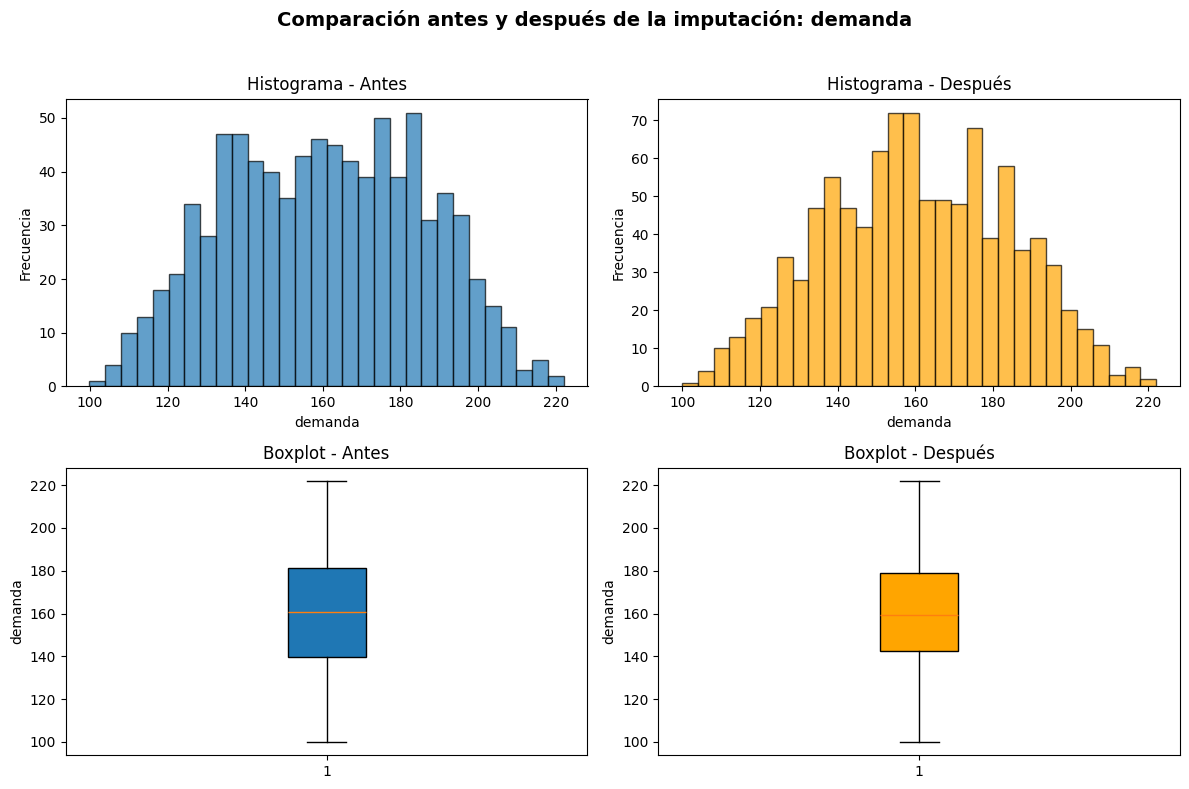

In [58]:
comparar_imputacion(df,df_imputado_Anorm_knn,variable="demanda")

En el histograma, se observa que después de la imputación por KNN la variable demanda conserva de manera general la forma de la distribución original, sin que se genere un pico artificial alrededor de la media como ocurrió con la imputación por regresión. La dispersión se mantiene y la concentración de valores sigue un patrón similar al de los datos iniciales, lo que indica que el método logró preservar mejor la variabilidad de la variable. En los boxplots, la mediana, la amplitud y la forma de la caja se mantienen prácticamente iguales antes y después de la imputación, lo cual refuerza la idea de que el KNN no introdujo distorsiones significativas en la estructura de los datos.

##### **Prueba Normalidad:**

In [59]:
prueba_normalidad(df_imputado_Anorm_knn,col_num_NoNorm)

Resultados de la prueba de Shapiro-Wilk:

Variable: edad                 | Estadístico: 0.9628 | p-valor: 2.8382e-15 | No Normal
Variable: demanda              | Estadístico: 0.9921 | p-valor: 3.7207e-05 | No Normal

Interpretación: p < 0.05 → No normal | p ≥ 0.05 → Normal


En la prueba de Shapiro-Wilk se observa que tanto la variable edad como la variable demanda presentan p-valores inferiores a 0.05, lo que indica que ninguna de ellas sigue una distribución normal.Estos resultados son consistentes con lo observado antes de la imputación, lo que sugiere que el método KNN no alteró de manera significativa la condición de no normalidad en ambas variables.

##### **Prueba Igualdad de Distribuciones:**

In [60]:
prueba_ks(df,df_imputado_Anorm_knn,col_num_NoNorm)

Resultados de Kolmogorov-Smirnov (KS test):

Variable: edad                 | KS Estadístico: 0.0085 | p-valor: 1.0000e+00 | Distribuciones Iguales
Variable: demanda              | KS Estadístico: 0.0395 | p-valor: 4.5503e-01 | Distribuciones Iguales

Interpretación: p < 0.05 → Distribuciones diferentes | p ≥ 0.05 → Distribuciones iguales


En la prueba de Kolmogorov-Smirnov se observa que tanto la variable edad como la variable demanda presentan p-valores superiores a 0.05, lo que indica que sus distribuciones antes y después de la imputación pueden considerarse estadísticamente iguales. En el caso de la edad, el estadístico obtenido (0.0085) y el p-valor de 1.0000 reflejan una coincidencia prácticamente perfecta entre ambas distribuciones. De manera similar, la demanda presenta un estadístico bajo (0.0395) y un p-valor de 0.4550, lo que confirma que no existen diferencias significativas en su forma. Estos resultados permiten concluir que el método KNN preservó de manera adecuada la distribución original de ambas variables.

##### **Comparación de medias**

In [61]:
comparar_mannwhitney(df,df_imputado_Anorm_regre,col_num_NoNorm)

Comparación de distribuciones con Mann–Whitney U:

Variable: edad                 | Estadístico: 485170.0000 | p-valor: 9.8928e-01 | No hay diferencia significativa
Variable: demanda              | Estadístico: 425618.0000 | p-valor: 9.5699e-01 | No hay diferencia significativa

Interpretación: p < 0.05 → diferencia significativa | p ≥ 0.05 → no significativa


En la prueba de Mann–Whitney U se observa que tanto la variable edad como la variable demanda presentan p-valores muy superiores a 0.05, lo que indica que no existen diferencias estadísticamente significativas entre las distribuciones antes y después de la imputación. En el caso de la edad, el estadístico (485170.0000) con un p-valor cercano a 1 refleja una alta similitud en el comportamiento de la variable tras la imputación. De manera similar, la demanda presenta un estadístico de 425618.0000 y un p-valor también muy elevado, lo que confirma que la imputación no generó alteraciones significativas en su tendencia central. Estos resultados sugieren que, desde un punto de vista estadístico, la imputación por KNN logró preservar adecuadamente las características de ambas variables.

##### **Conclusión:**

A partir de la comparación gráfica y de los resultados de las pruebas estadísticas, se puede concluir que la imputación por KNN fue un método adecuado para completar los valores faltantes tanto en la variable edad como en la variable demanda. En los histogramas y boxplots no se evidencian cambios drásticos en la forma de las distribuciones, ya que la tendencia central, la dispersión y la variabilidad original se conservaron de manera consistente. Esto fue respaldado por las pruebas de Kolmogorov-Smirnov y Mann–Whitney U, que indicaron que no existen diferencias significativas entre las distribuciones antes y después de la imputación. Los hallazgos permiten afirmar que KNN preservó de forma más fiel las propiedades originales de los datos en comparación con la imputación por regresión, especialmente en la variable demanda, donde se mantuvo la variabilidad sin generar concentraciones artificiales.

## **5.3. Imputación Categoricas:**

In [62]:
col_cat = ["estado_civil","segmento","nivel_educativo","ciudad","sexo"]

#### **5.3.1. Moda:**

In [63]:
# Crear copia del DataFrame original
df_imputado_cat_mode = df.copy()

# Imputar NaN con la moda
for col in col_cat:
    moda = df[col].mode()[0]   # la moda puede devolver varios valores, se toma el primero
    df_imputado_cat_mode[col] = df[col].fillna(moda)

##### **`Estado_civil`:**

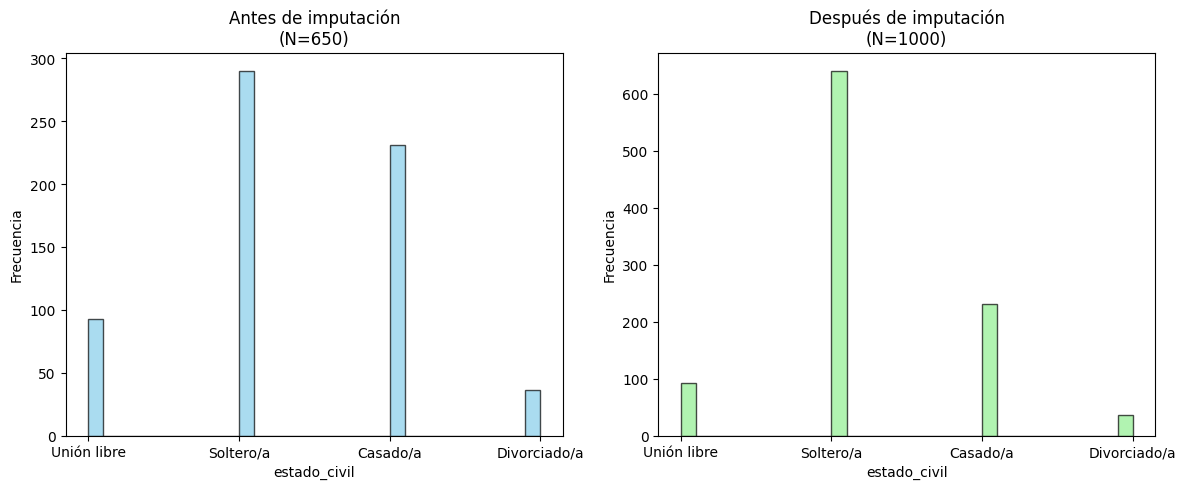

In [64]:
comparar_distribucion_imputacion(df,df_imputado_cat_mode,"estado_civil")

En los gráficos de barras se observa que, antes de la imputación, la distribución del estado civil mostraba un predominio de las categorías “Soltero/a” y “Casado/a”, seguidas por “Unión libre” y “Divorciado/a” con menor frecuencia. Tras la imputación por moda, la categoría dominante (“Soltero/a”) incrementó de manera considerable su frecuencia, mientras que las demás categorías permanecieron prácticamente iguales en número absoluto, lo que provocó un aumento desproporcionado en el peso relativo de la moda dentro de la distribución.


##### **`Segmento:`**

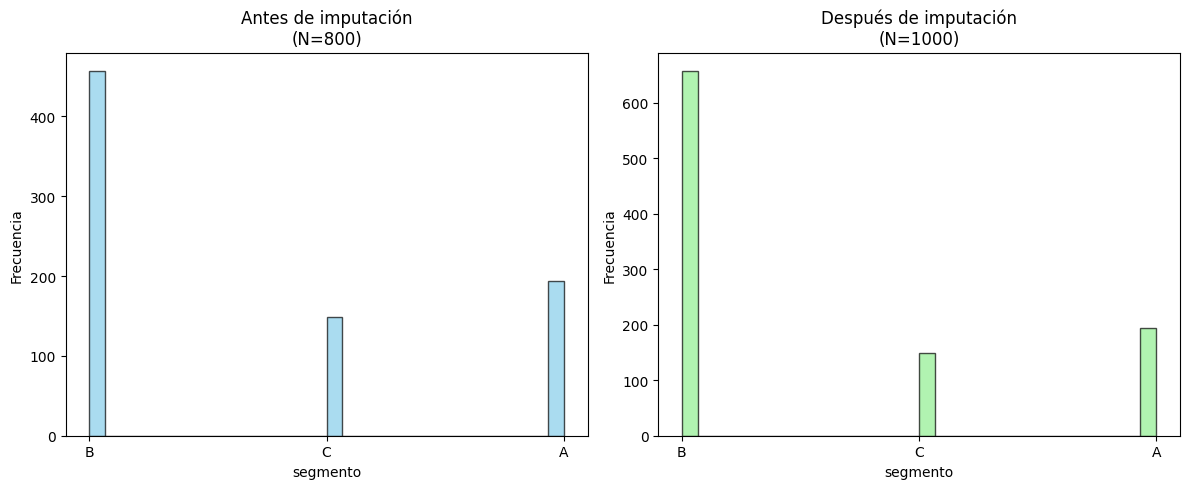

In [65]:
comparar_distribucion_imputacion(df,df_imputado_cat_mode,"segmento")

En los gráficos de la variable segmento, se observa que antes de la imputación la distribución estaba concentrada en la categoría B (mayoritaria), seguida de A y finalmente C con menor frecuencia. Después de la imputación por moda, la categoría modal (B) aumentó de manera notable, mientras que las categorías A y C prácticamente no variaron en su frecuencia absoluta.

##### **`nivel_educativo`:**

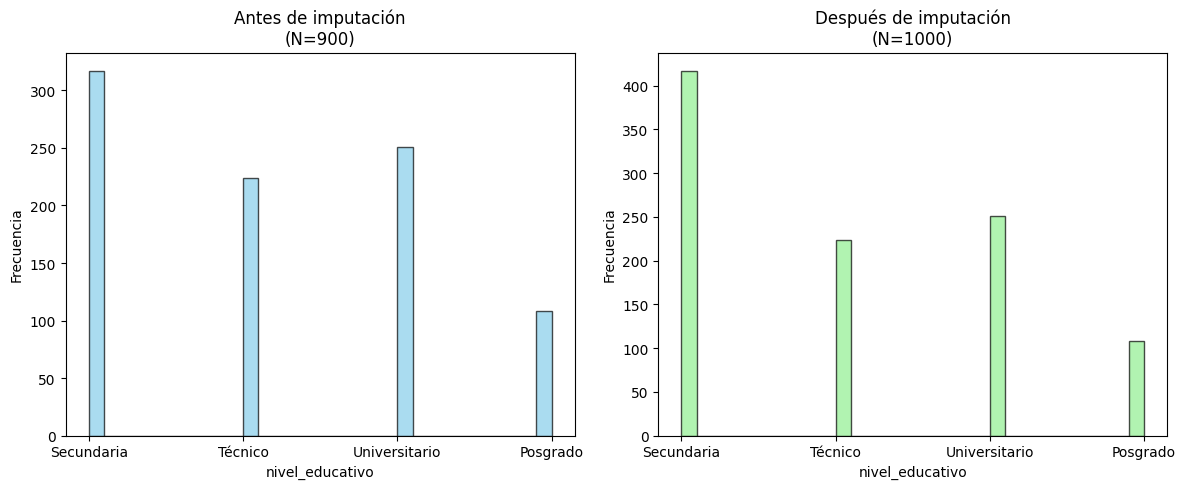

In [66]:
comparar_distribucion_imputacion(df,df_imputado_cat_mode,"nivel_educativo")

En el caso de la variable nivel_educativo, antes de la imputación la distribución estaba relativamente equilibrada entre Secundaria y Universitario, con valores intermedios en Técnico y menor frecuencia en Posgrado.Tras la imputación por moda, la categoría Secundaria (la más frecuente inicialmente) se incrementó de manera marcada, aumentando su peso relativo en la distribución. Las demás categorías (Técnico, Universitario y Posgrado) se mantuvieron casi sin cambios absolutos, pero perdieron participación en el total de la muestra.

##### **`ciudad`:**

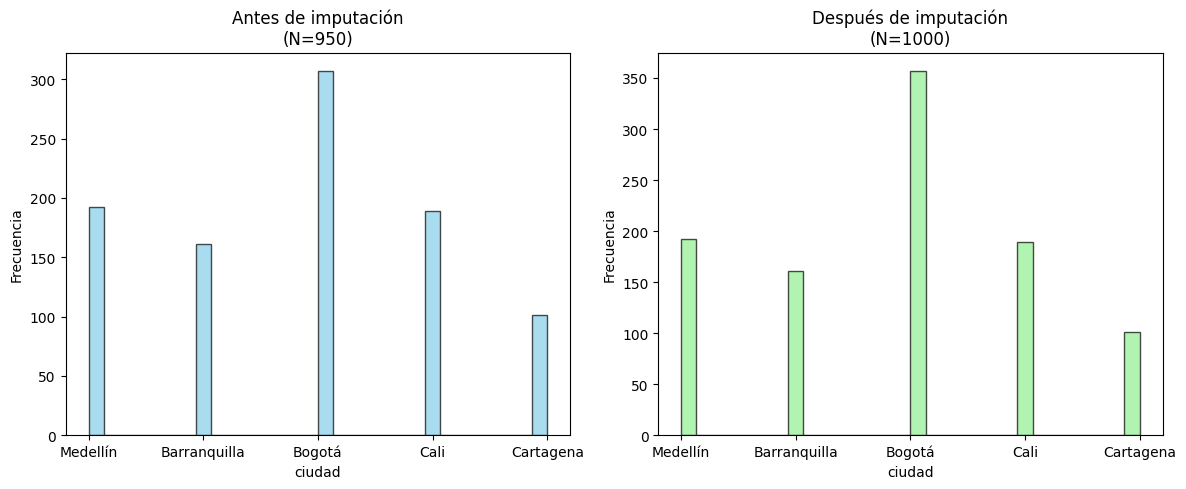

In [67]:
comparar_distribucion_imputacion(df,df_imputado_cat_mode,"ciudad")

En la variable ciudad, antes de la imputación la distribución estaba relativamente balanceada entre Medellín, Barranquilla y Cali, con Bogotá como la categoría más frecuente y Cartagena como la menos representada. Tras la imputación por moda, se observa que la categoría Bogotá (la más frecuente antes de la imputación) aumentó aún más su frecuencia, mientras que las demás ciudades se mantuvieron casi constantes en valores absolutos. Esto genera un sesgo hacia Bogotá, reduciendo la proporción relativa de las demás ciudades en el conjunto de datos.

##### **`sexo`:**

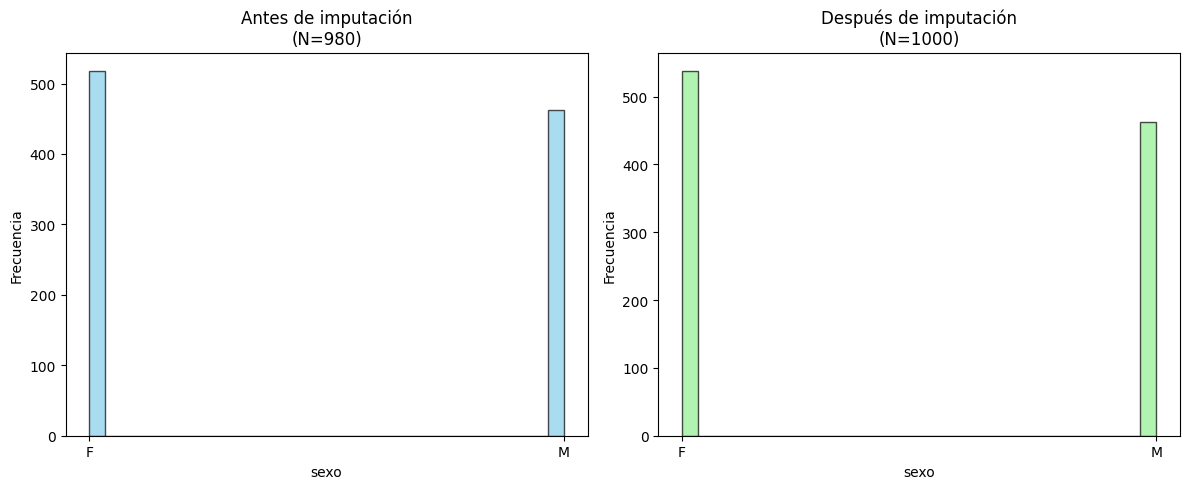

In [68]:
comparar_distribucion_imputacion(df,df_imputado_cat_mode,"sexo")

En la variable sexo, antes de la imputación ya existía un ligero predominio de la categoría Femenino (F) frente a Masculino (M). Tras aplicar la imputación por moda, se observa que el total de casos aumentó y que la categoría Femenino, al ser la más frecuente, fue la seleccionada para imputar los valores faltantes. Esto refuerza aún más el desequilibrio entre las dos categorías, aumentando la brecha en la distribución.

##### **Chi-Cuadrado:**

In [81]:
chi2_imputacion(df,df_imputado_cat_mode,col_cat)

,Variable,Chi2,p-valor,GL,Conclusión
0,estado_civil,60.186104,5.363963e-13,3,Distribuciones diferentes
1,segmento,13.855476,9.802157e-04,2,Distribuciones diferentes
2,nivel_educativo,8.384045,3.870693e-02,3,Distribuciones diferentes
3,ciudad,2.484643,6.473879e-01,4,Distribuciones iguales
4,sexo,0.140932,7.073557e-01,1,Distribuciones iguales


Los resultados del análisis con la prueba de Chi-cuadrado muestran que la imputación por moda afectó de manera significativa la distribución de algunas variables categóricas, en particular estado civil, segmento y nivel educativo, donde se observa un refuerzo de las categorías más frecuentes que altera el equilibrio original de los datos. Por el contrario, en las variables ciudad y sexo no se encontraron diferencias estadísticamente significativas, lo que indica que la imputación no modificó su estructura distributiva.

#### **5.3.2. Hot-deck:**

In [69]:
# Crear copia del DataFrame original
df_imputado_hotdeck = df.copy()

# Imputar valores faltantes con Hot-Deck (seleccionando aleatoriamente de valores observados)
for col in col_cat:
    valores_existentes = df[col].dropna().unique()  # categorías disponibles
    n_missing = df[col].isna().sum()
    
    if n_missing > 0:
        imputacion = np.random.choice(valores_existentes, size=n_missing, replace=True)
        df_imputado_hotdeck.loc[df[col].isna(), col] = imputacion

##### **`Estado_civil:`**

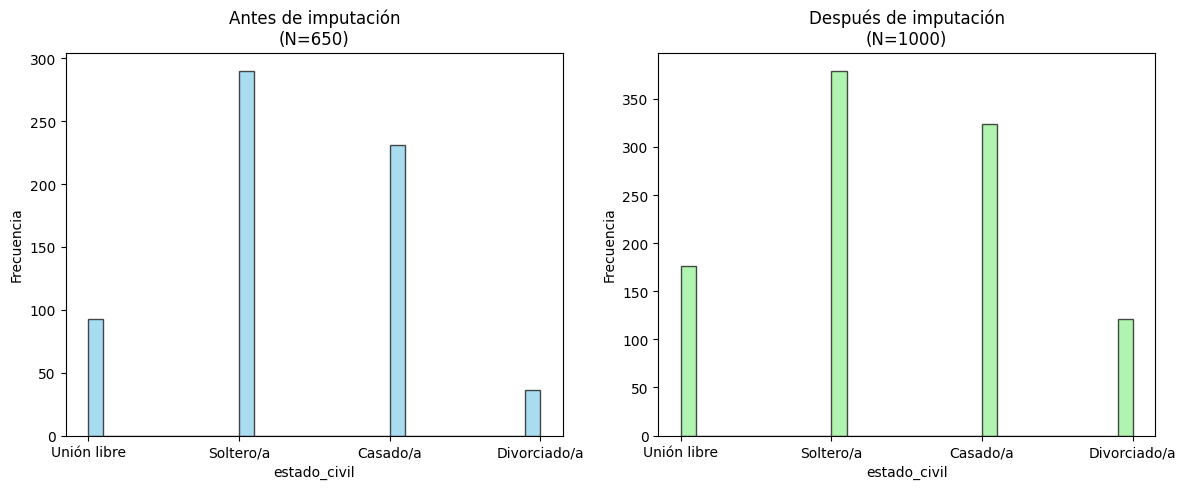

In [70]:
comparar_distribucion_imputacion(df,df_imputado_hotdeck,"estado_civil")

Los histogramas muestran que la distribución de categorías después de la imputación mantiene una estructura proporcionalmente coherente con la distribución original, aunque con un aumento esperado en las frecuencias absolutas debido al mayor tamaño muestral.

##### **`Segmento:`**

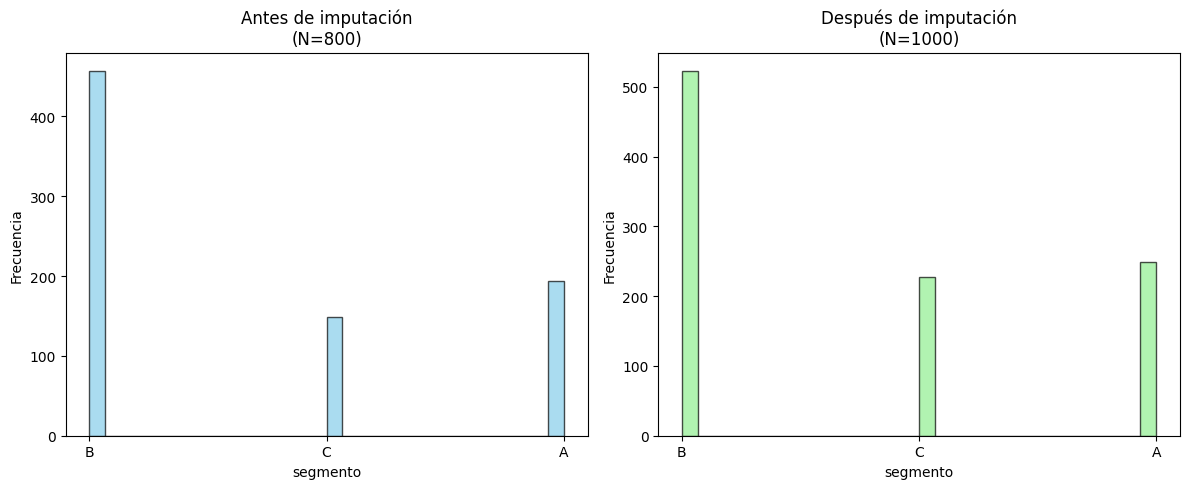

In [71]:
comparar_distribucion_imputacion(df,df_imputado_hotdeck,"segmento")

En la variable segmento, antes de la imputación se observaba que la categoría B era la más frecuente, seguida de A y luego C, con una distribución claramente desigual entre los grupos. Tras la imputación por Hotdeck, las tres categorías aumentaron su frecuencia absoluta, manteniendo a B como la categoría predominante, pero con un crecimiento proporcional mayor en A y C. Esto generó una distribución más equilibrada entre los segmentos, reduciendo parcialmente la concentración inicial en B.

##### **`nivel_educativo`:**

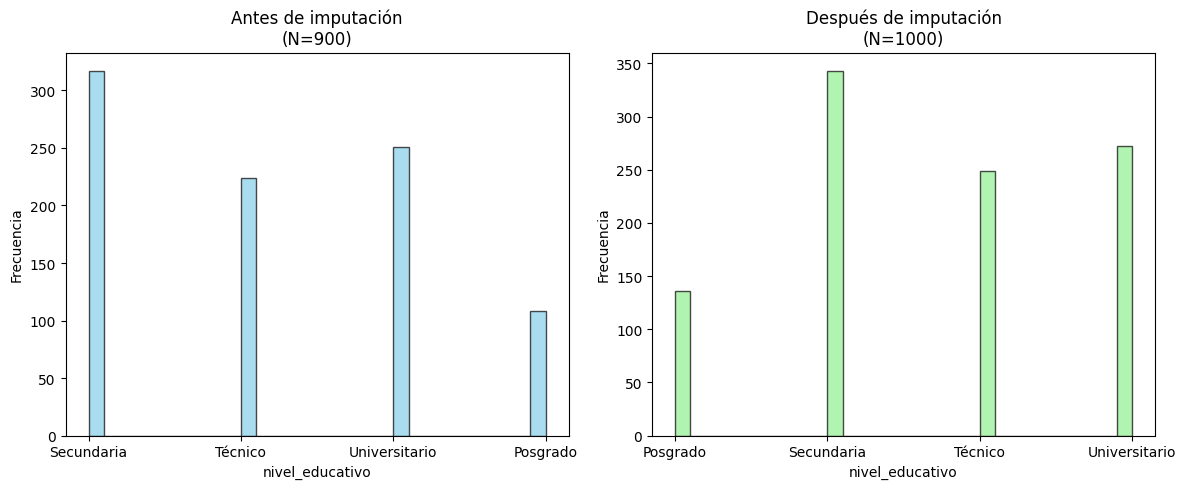

In [72]:
comparar_distribucion_imputacion(df,df_imputado_hotdeck,"nivel_educativo")

En la variable nivel educativo, antes de la imputación la categoría Secundaria era la más frecuente, seguida de Universitario y Técnico, mientras que Posgrado presentaba la menor representación. Tras la imputación por Hotdeck, todas las categorías aumentaron en frecuencia absoluta, manteniéndose Secundaria como la predominante, pero con un incremento proporcional también en Técnico y Universitario, y en menor medida en Posgrado. Esto generó una distribución más balanceada entre los niveles educativos, aunque la concentración en Secundaria continúa siendo la más alta.

##### **`ciudad`:**

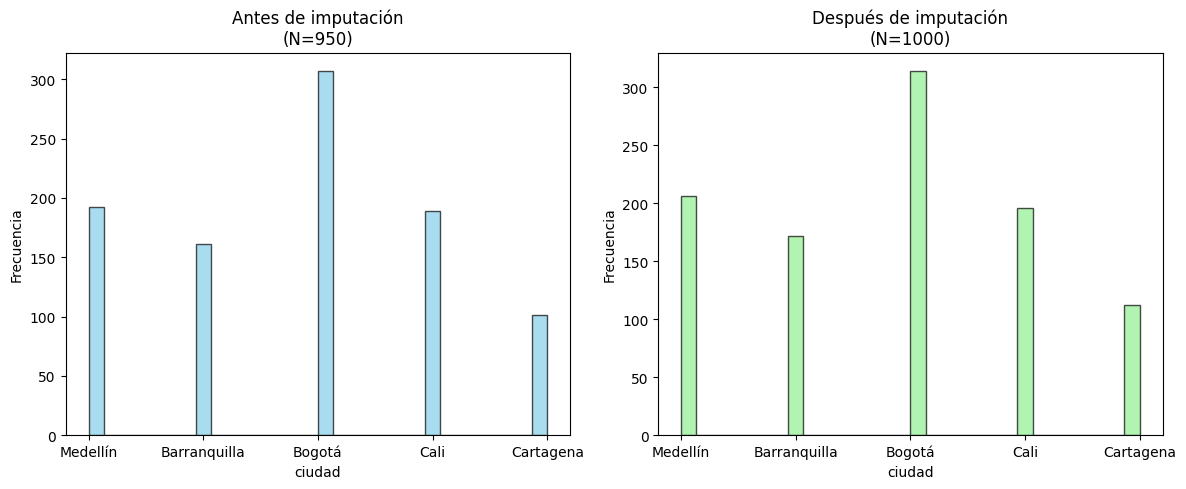

In [73]:
comparar_distribucion_imputacion(df,df_imputado_hotdeck,"ciudad")

En la variable ciudad, antes de la imputación la categoría más frecuente era Bogotá, seguida de Medellín y Cali, mientras que Barranquilla y especialmente Cartagena presentaban menor representación. Tras la imputación por Hotdeck, todas las ciudades aumentaron en frecuencia absoluta, manteniéndose Bogotá como la categoría predominante, aunque con crecimientos también visibles en las demás, lo que permitió conservar la estructura general de la distribución sin generar un sesgo marcado hacia una sola ciudad.

##### **`sexo`:**

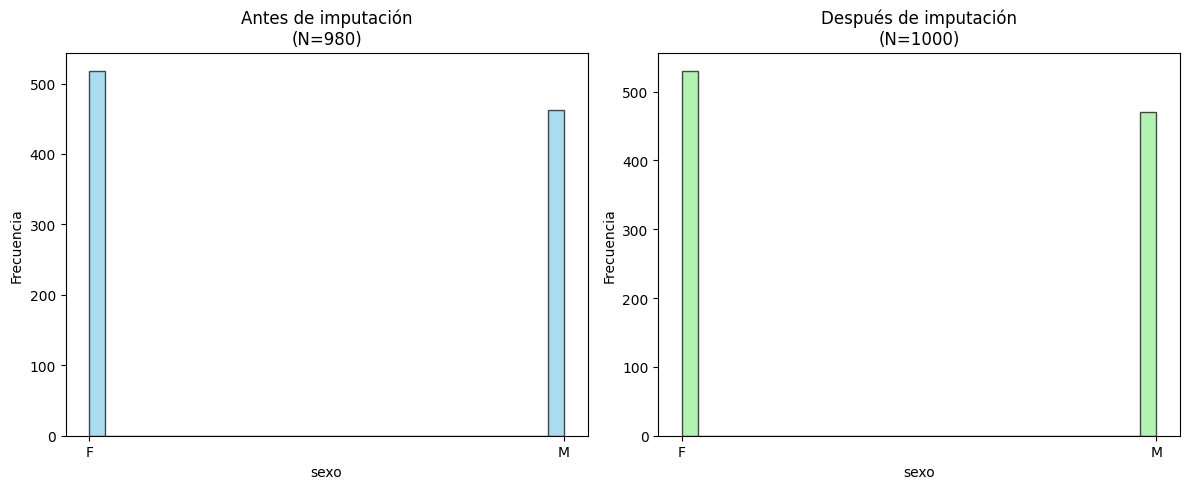

In [74]:
comparar_distribucion_imputacion(df,df_imputado_hotdeck,"sexo")

En la variable sexo, antes de la imputación la distribución estaba relativamente equilibrada entre mujeres y hombres, aunque con una ligera mayor frecuencia en la categoría femenina. Tras la imputación por Hotdeck, ambas categorías aumentaron en frecuencia absoluta, manteniéndose el predominio de las mujeres y conservándose el balance general entre los dos grupos, sin generar un sesgo importante hacia alguno de ellos.

##### **Chi-Cuadrado:**

In [82]:
chi2_imputacion(df,df_imputado_hotdeck,col_cat)

,Variable,Chi2,p-valor,GL,Conclusión
0,estado_civil,25.979135,0.000010,3,Distribuciones diferentes
1,segmento,5.675564,0.058555,2,Distribuciones iguales
2,nivel_educativo,1.141928,0.766963,3,Distribuciones iguales
3,ciudad,0.348256,0.986490,4,Distribuciones iguales
4,sexo,0.000348,0.985123,1,Distribuciones iguales


Los resultados del análisis con la prueba de Chi-cuadrado muestran que la imputación por Hotdeck afectó de manera significativa únicamente la distribución de la variable estado civil, donde se evidencian cambios estadísticamente relevantes respecto a la estructura original. En contraste, las variables segmento, nivel educativo, ciudad y sexo no presentaron diferencias significativas, lo que indica que la imputación mantuvo en gran medida sus distribuciones originales sin introducir sesgos notables.

#### **5.3.3. KNN:**

In [75]:
df_imputado_cat_knn = df.copy()

# 1. Codificar las variables categóricas en números
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df_imputado_cat_knn[col_cat] = encoder.fit_transform(df_imputado_cat_knn[col_cat])

# 2. Imputar con KNN
imputer = KNNImputer(n_neighbors=5)
df_imputado_cat_knn[col_cat] = imputer.fit_transform(df_imputado_cat_knn[col_cat])

# 3. Redondear (para asegurarnos de recuperar categorías válidas)
df_imputado_cat_knn[col_cat] = np.round(df_imputado_cat_knn[col_cat])

# 4. Convertir de nuevo a categorías originales
df_imputado_cat_knn[col_cat] = encoder.inverse_transform(df_imputado_cat_knn[col_cat])

##### **`Estado_civil:`**

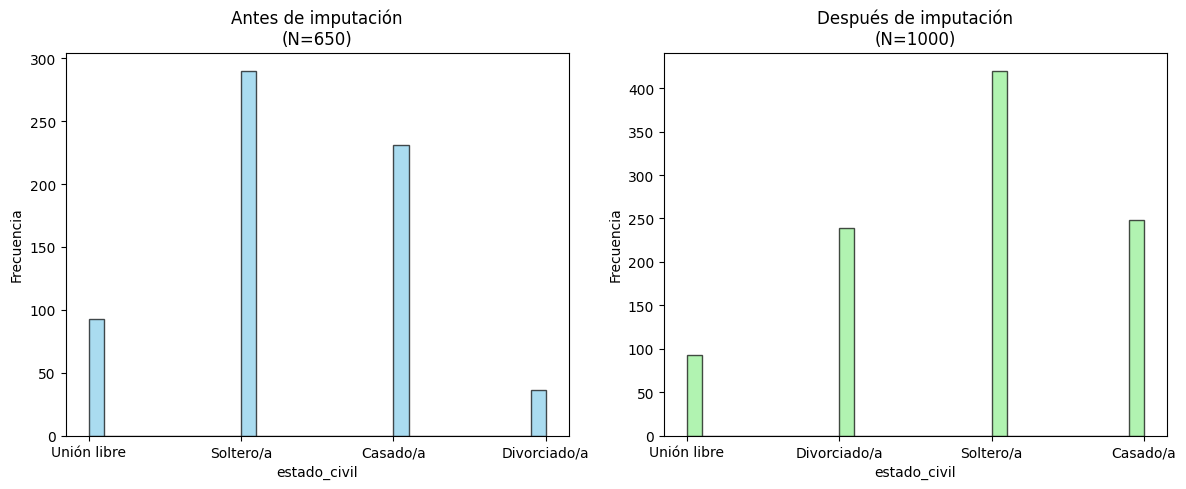

In [76]:
comparar_distribucion_imputacion(df,df_imputado_cat_knn,"estado_civil")

En la variable estado civil, antes de la imputación la categoría más frecuente era Soltero/a, seguida de Casado/a, mientras que Unión libre y especialmente Divorciado/a tenían una representación mucho menor. Tras la imputación con KNN, todas las categorías aumentaron en frecuencia absoluta, pero se observa un crecimiento notable en Divorciado/a, que pasó de ser la menos representada a alcanzar una frecuencia similar a la de Casado/a. Esto modificó de manera significativa la distribución original, manteniendo a Soltero/a como la categoría predominante, pero reduciendo la brecha respecto a las demás categorías y alterando el equilibrio inicial de los datos.

##### **`Segmento:`**

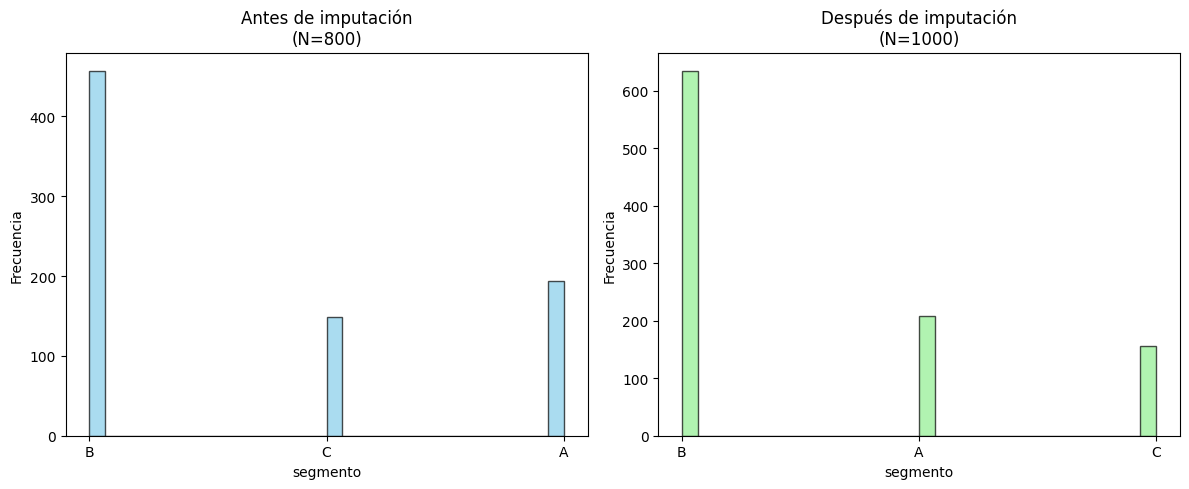

In [77]:
comparar_distribucion_imputacion(df,df_imputado_cat_knn,"segmento")

En la variable segmento, antes de la imputación la categoría más frecuente era B, seguida de A y luego C, con una distribución claramente desigual. Tras la imputación con KNN, todas las categorías aumentaron en frecuencia absoluta, pero el crecimiento fue mucho mayor en B, que reforzó aún más su predominio en el conjunto de datos. Esto generó un sesgo hacia la categoría mayoritaria, reduciendo proporcionalmente la representación de A y C y alterando el equilibrio inicial de la distribución.

##### **`nivel_educativo`:**

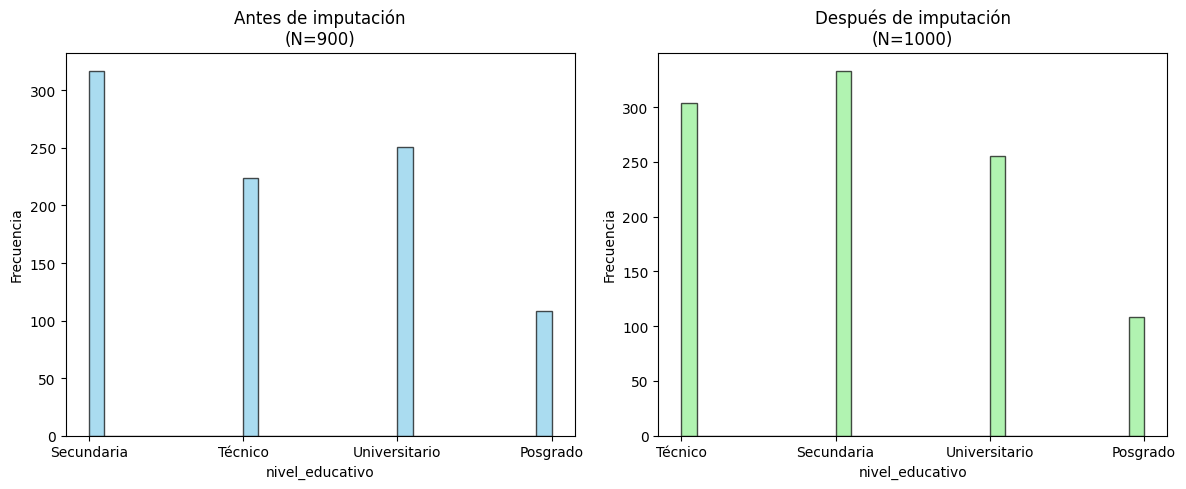

In [78]:
comparar_distribucion_imputacion(df,df_imputado_cat_knn,"nivel_educativo")

En la variable nivel educativo, antes de la imputación la categoría Secundaria era la más frecuente, seguida de Universitario y Técnico, mientras que Posgrado presentaba la menor representación. Tras la imputación con KNN, Secundaria se mantuvo como la categoría predominante, pero Técnico aumentó considerablemente en frecuencia, alcanzando un nivel similar al de Secundaria y desplazando a Universitario al tercer lugar. Esto modificó la estructura original de la distribución, reduciendo la brecha entre las categorías más representadas y alterando el equilibrio inicial de los datos.

##### **`ciudad`:**

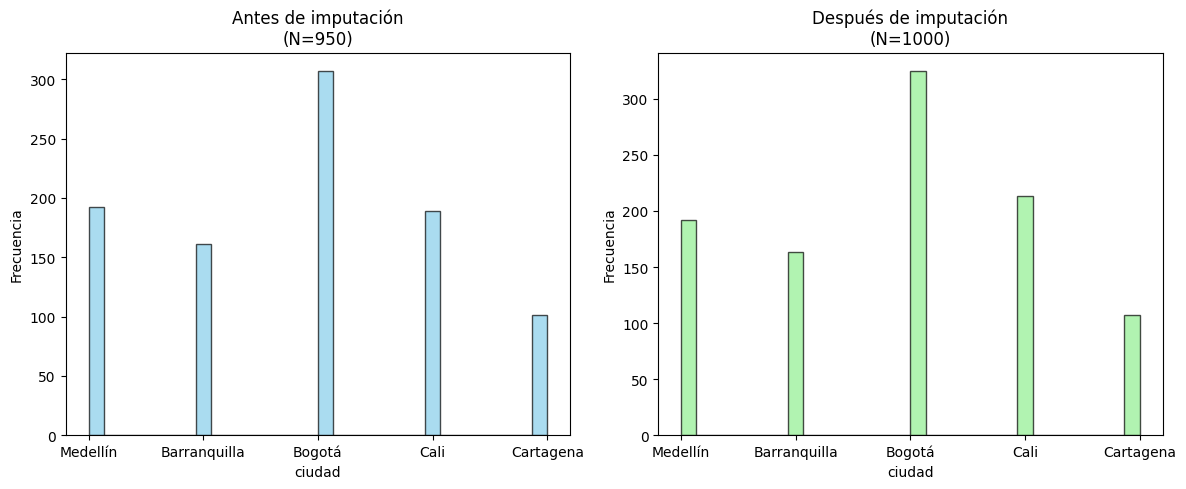

In [79]:
comparar_distribucion_imputacion(df,df_imputado_cat_knn,"ciudad")

En la variable ciudad, antes de la imputación la categoría más frecuente era Bogotá, seguida de Medellín y Cali, mientras que Barranquilla y Cartagena tenían menor representación. Tras la imputación con KNN, todas las ciudades aumentaron en frecuencia absoluta, manteniéndose Bogotá como la predominante y ampliando ligeramente su ventaja respecto a las demás. Aunque la estructura general de la distribución se conservó, el refuerzo en la categoría mayoritaria generó un leve incremento en el sesgo hacia Bogotá.

##### **`sexo`:**

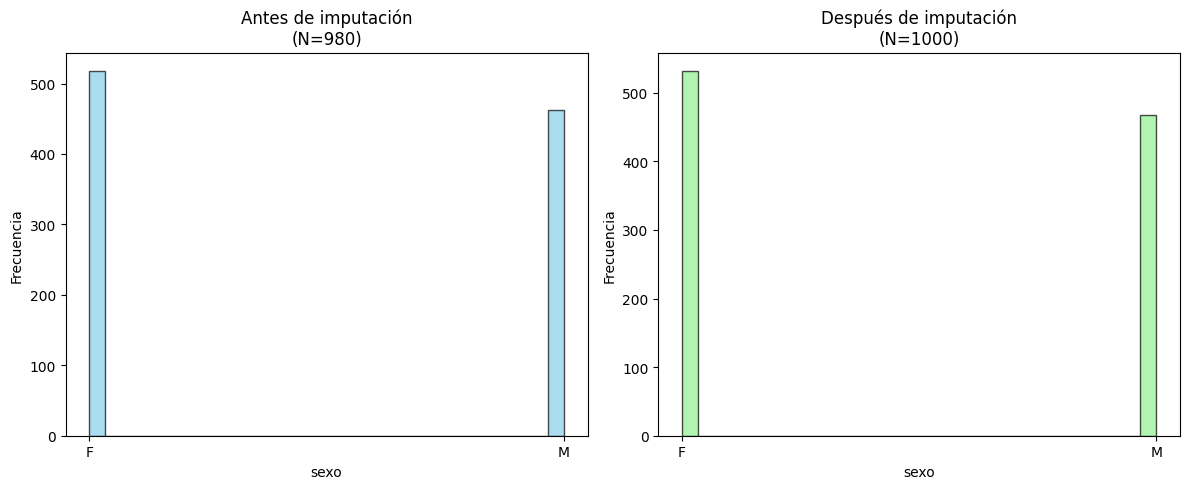

In [80]:
comparar_distribucion_imputacion(df,df_imputado_cat_knn,"sexo")

En la variable sexo, antes de la imputación se observaban 980 registros, con ligera predominancia del sexo femenino sobre el masculino. Tras la imputación con KNN, el número de observaciones aumentó a 1000 y se reforzó la presencia femenina, manteniendo la misma relación de mayor frecuencia en mujeres respecto a hombres. En general, la distribución no cambió de manera drástica, pero sí se incrementó la proporción de mujeres en comparación con hombres, mostrando un leve sesgo hacia la categoría femenina.

##### **Chi-Cuadrado:**

In [83]:
chi2_imputacion(df,df_imputado_cat_knn,col_cat)

,Variable,Chi2,p-valor,GL,Conclusión
0,estado_civil,104.726870,1.495916e-22,3,Distribuciones diferentes
1,segmento,7.582757,2.256448e-02,2,Distribuciones diferentes
2,nivel_educativo,7.303753,6.282118e-02,3,Distribuciones iguales
3,ciudad,0.849424,9.317020e-01,4,Distribuciones iguales
4,sexo,0.011622,9.141518e-01,1,Distribuciones iguales


Los resultados del análisis con la prueba de Chi-cuadrado muestran que la imputación con KNN modificó de forma significativa la distribución de las variables estado civil y segmento, lo que indica que en estas categorías se introdujeron cambios que alteraron su equilibrio original. Por el contrario, en nivel educativo, ciudad y sexo no se encontraron diferencias estadísticamente significativas, lo que sugiere que la imputación preservó su estructura distributiva inicial.

#### **5.3.4. Conclusiones:**

En conclusión, la imputación por moda resultó más efectiva para las variables ciudad y sexo, ya que no generó cambios significativos en sus distribuciones, mientras que la imputación con KNN fue más adecuada para nivel educativo, manteniendo estable su estructura.Por otro lado, en segmento la tecnica de imputación por Hot-Deck fue mas efectiva al no moestrar cambios estadisticamente significativos despues del proceso. En cambio, en estado civil  ninguna de las tres técnicas logró preservar totalmente la distribución original..  

# **6. Conclusión Preliminar**

| Variable            | % Nulos | Tipo de ausencia | Método sugerido de imputación | Evidencia sobre distribución |
|---------------------|---------|------------------|--------------------------------|------------------------------|
| **Estado civil**    | 35%      | MCAR              | Modelos Avanzados                           | Ninguna tecnica utilizada dio resultados positivos |
| **Segmento**        | 20%      | MCAR             | Hot-Deck                           | Chi²: distribuciones iguales |
| **Nivel educativo** | 10%      | MAR             | Hot-Deck                           | Chi²: distribuciones iguales |
| **Ciudad**          | 5%      | MCAR             | Moda                           | Chi²: distribuciones iguales  |
| **Sexo**            | 2%      | MCAR             | Moda                           | Chi²: distribuciones iguales  |
| **Altura (cm)**     | 8%      | MAR             | KNN    | Pruebas de normalidad, igualdad de distribuciones y comparación de medias revelan que no hubo cambios |
| **Ingresos**        | 12%      | MAR              | Regresión                | Pruebas de normalidad, igualdad de distribuciones y comparación de medias revelan que no hubo cambios |
| **Gasto mensual**   | 25%      | MAR              | Regresión               | Pruebas de normalidad, igualdad de distribuciones y comparación de medias revelan que no hubo cambios|
| **Puntuación crédito** | 50%   | MCAR             | Modelos avanzados | Ninguna de las tecnicas aplicadas fue lo suficientemente buena|
| **Edad**            | 3%      | MAR             | KNN                       | Pruebas de normalidad, igualdad de distribuciones y comparación de medias revelan que no hubo cambios |
| **Demanda**         | 15%      | MAR              | KNN| Pruebas de normalidad, igualdad de distribuciones y comparación de medias revelan que no hubo cambios |
